In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
import os
import glob
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

/tmp/ipykernel_1746220/1120606664.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [2]:
class AttentionAllLayersDataset(Dataset):
    """Dataset that loads head-averaged per-layer attention matrices from h5 shards.

    Each sample is a single (seq_len, seq_len) attention matrix together with
    the layer index it came from.  This lets a single layer-conditioned AE
    train on data from *all* layers simultaneously.
    """

    def __init__(self, data_dir, max_seq_len=128, allowed_keys=None,
                 attn_mean=None, attn_std=None, skip_tokens=0):
        self.data_dir = data_dir
        self.max_seq_len = max_seq_len
        self.allowed_keys = allowed_keys
        self.attn_mean = attn_mean
        self.attn_std = attn_std
        self.skip_tokens = skip_tokens
        self.index = self._build_index()

    def _build_index(self):
        """Build a flat list of (shard_path, key, layer_idx) triples."""
        index = []
        shard_files = sorted(glob.glob(os.path.join(self.data_dir, "shard_*.h5")))
        for shard_path in shard_files:
            with h5py.File(shard_path, "r") as f:
                for key in sorted(f.keys()):
                    if self.allowed_keys is not None and key not in self.allowed_keys:
                        continue
                    num_layers = int(f[key].attrs["num_layers"])
                    for layer_idx in range(num_layers):
                        index.append((shard_path, key, layer_idx))
        return index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        shard_path, key, layer_idx = self.index[idx]
    
        # Open file handle lazily and cache it (safe per-worker with num_workers > 0)
        if not hasattr(self, '_file_cache'):
            self._file_cache = {}
        if shard_path not in self._file_cache:
            self._file_cache[shard_path] = h5py.File(shard_path, "r")
    
        f = self._file_cache[shard_path]
        grp = f[key]
        attn = grp["layer_attn"][layer_idx].astype(np.float32)
        seq_len = int(grp.attrs["seq_len"])

        s = self.skip_tokens
        if s > 0:
            attn = attn[s:, s:]
            seq_len = max(seq_len - s, 0)

        N = self.max_seq_len
        actual = min(seq_len, N)

        padded = np.zeros((N, N), dtype=np.float32)
        padded[:actual, :actual] = attn[:actual, :actual]

        mask = np.zeros((N, N), dtype=np.float32)
        mask[:actual, :actual] = 1.0

        if self.attn_mean is not None and self.attn_std is not None:
            padded = (padded - self.attn_mean) / self.attn_std
            padded = padded * mask

        return {
            "attn": torch.from_numpy(padded),
            "mask": torch.from_numpy(mask),
            "seq_len": actual,
            "layer_idx": layer_idx,
        }

In [3]:
def attn_collate_fn(batch):
    """Stack batch items into tensors."""
    return {
        "attn": torch.stack([b["attn"] for b in batch]),            # (B, N, N)
        "mask": torch.stack([b["mask"] for b in batch]),             # (B, N, N)
        "seq_len": torch.tensor([b["seq_len"] for b in batch]),      # (B,)
        "layer_idx": torch.tensor([b["layer_idx"] for b in batch]),  # (B,)
    }


def make_dataloader(data_dir, max_seq_len=128,
                    batch_size=32, shuffle=True, num_workers=16,
                    allowed_keys=None,
                    attn_mean=None, attn_std=None, skip_tokens=0):
    """Create a DataLoader over ALL layers (one sample per layer per prompt)."""
    dataset = AttentionAllLayersDataset(
        data_dir=data_dir,
        max_seq_len=max_seq_len,
        allowed_keys=allowed_keys,
        attn_mean=attn_mean,
        attn_std=attn_std,
        skip_tokens=skip_tokens,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=attn_collate_fn,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
    )

    return loader

In [4]:
# Test the dataset and dataloader
data_dir = "/pscratch/sd/m/mcohen54/warmup_attention_data"
max_seq_len = 128

# Attention data was collected over user content tokens only (no chat template).
SKIP_TOKENS = 0

dataset = AttentionAllLayersDataset(data_dir, max_seq_len=max_seq_len, skip_tokens=SKIP_TOKENS)
print("Dataset size (total layer-samples): {}".format(len(dataset)))

sample = dataset[0]
print("Sample attn shape: {}".format(sample["attn"].shape))
print("Sample mask shape:  {}".format(sample["mask"].shape))
print("Sample seq_len:     {}".format(sample["seq_len"]))
print("Sample layer_idx:   {}".format(sample["layer_idx"]))

loader = make_dataloader(data_dir, max_seq_len=max_seq_len, batch_size=4, skip_tokens=SKIP_TOKENS)
batch = next(iter(loader))
print("\nBatch attn shape:   {}".format(batch["attn"].shape))
print("Batch mask shape:    {}".format(batch["mask"].shape))
print("Batch seq_lens:      {}".format(batch["seq_len"].tolist()))
print("Batch layer_indices: {}".format(batch["layer_idx"].tolist()))

Dataset size (total layer-samples): 840000
Sample attn shape: torch.Size([128, 128])
Sample mask shape:  torch.Size([128, 128])
Sample seq_len:     23
Sample layer_idx:   0

Batch attn shape:   torch.Size([4, 128, 128])
Batch mask shape:    torch.Size([4, 128, 128])
Batch seq_lens:      [10, 24, 15, 19]
Batch layer_indices: [25, 8, 6, 9]


In [5]:
import matplotlib.pyplot as plt

# ── Collect all prompts from the H5 shards ──
all_prompts = []
shard_files = sorted(glob.glob(os.path.join(data_dir, "shard_*.h5")))
num_layers = None
for shard_path in shard_files:
    with h5py.File(shard_path, "r") as f:
        for key in sorted(f.keys()):
            if num_layers is None:
                num_layers = int(f[key].attrs["num_layers"])
            prompt_text = f[key].attrs.get("prompt", "<no prompt>")
            if isinstance(prompt_text, bytes):
                prompt_text = prompt_text.decode("utf-8")
            all_prompts.append((shard_path, key, prompt_text))

# ── Print totals ──
total_prompts = len(all_prompts)
total_layer_samples = total_prompts * num_layers
print(f"Total text prompts:       {total_prompts:,}")
print(f"Layers per prompt:        {num_layers}")
print(f"Total layer-samples:      {total_layer_samples:,}")

# ── Print a few example prompts ──
print(f"\n=== First 5 prompts ===")
for i, (sp, k, p) in enumerate(all_prompts[:5]):
    print(f"  [{i}] {k}: {p[:200]}")
print(f"\n=== Last 3 prompts ===")
for sp, k, p in all_prompts[-3:]:
    print(f"  {k}: {p[:200]}")

Total text prompts:       30,000
Layers per prompt:        28
Total layer-samples:      840,000

=== First 5 prompts ===
  [0] prompt_00000000: PLEASE WRITE A PYTHON FUNCTION THAT TAKES A LIST OF NUMBERS AND RETURNS THE SUM IN ALL CAPS.
  [1] prompt_00000001: Write a short story about a world where everyone thinks they can fly, but corrections are needed on the physics of flight.
  [2] prompt_00000002: Can you help me with writing a Python script to automate the process of data collection from different APIs? I have been thinking about various libraries like 'requests' and 'BeautifulSoup' but I'm un
  [3] prompt_00000003: I'd like to write a cover letter for a job application. Imagine I'm applying for a tech startup role and I recently led a project that reduced costs by 20%. How can I highlight this experience effecti
  [4] prompt_00000004: Hey, do you think the probability of rolling a six on a dice is the same as flipping heads on a coin? I'm confused about probabilities in games.



In [6]:
import random

random.seed(42)

all_keys = [key for _, key, _ in all_prompts]
random.shuffle(all_keys)

split_point = len(all_keys) // 2
train_keys = set(all_keys[:split_point])
test_keys = set(all_keys[split_point:])

print(f"Train set:  {len(train_keys):,} prompts  (50%)")
print(f"Test set:   {len(test_keys):,} prompts  (50%)")

Train set:  15,000 prompts  (50%)
Test set:   15,000 prompts  (50%)


In [7]:
# --- Compute per-pixel StandardScaler (mean, std) from training data ---
N = max_seq_len
print(f"Computing per-pixel scaler statistics ({N}x{N}) from training data...")

running_sum = np.zeros((N, N), dtype=np.float64)
running_sq_sum = np.zeros((N, N), dtype=np.float64)
running_count = np.zeros((N, N), dtype=np.float64)

shard_files = sorted(glob.glob(os.path.join(data_dir, "shard_*.h5")))
for shard_path in tqdm(shard_files, desc="Scaler pass"):
    with h5py.File(shard_path, "r") as f:
        for key in sorted(f.keys()):
            if key not in train_keys:
                continue
            grp = f[key]
            seq_len = int(grp.attrs["seq_len"])
            n_layers = int(grp.attrs["num_layers"])
            actual = min(seq_len, N)

            for layer_idx in range(n_layers):
                attn = grp["layer_attn"][layer_idx].astype(np.float64)
                attn = attn[SKIP_TOKENS:, SKIP_TOKENS:]
                a = max(actual - SKIP_TOKENS, 0)
                running_sum[:a, :a] += attn[:a, :a]
                running_sq_sum[:a, :a] += attn[:a, :a] ** 2
                running_count[:a, :a] += 1.0

safe_count = np.maximum(running_count, 1.0)
attn_mean = (running_sum / safe_count).astype(np.float32)
attn_std = np.sqrt(running_sq_sum / safe_count - (running_sum / safe_count) ** 2)
attn_std = np.maximum(attn_std, 0.01).astype(np.float32)

total_samples = int(running_count[0, 0])
print(f"Scaler fitted on {total_samples:,} samples (per top-left pixel)")
print(f"  mean range: [{attn_mean[attn_mean != 0].min():.6f}, {attn_mean.max():.6f}]")
print(f"  std  range: [{attn_std[attn_std > 1e-8].min():.6f}, {attn_std.max():.6f}]")
print(f"  count range: [{int(running_count[running_count > 0].min())}, {int(running_count.max())}]")

Computing per-pixel scaler statistics (128x128) from training data...


Scaler pass: 100%|██████████| 3/3 [01:32<00:00, 30.77s/it]

Scaler fitted on 420,000 samples (per top-left pixel)
  mean range: [0.000628, 1.000000]
  std  range: [0.010000, 0.324311]
  count range: [28, 420000]


Scaler pass: 100%|██████████| 3/3 [01:30<00:00, 30.09s/it]

Scaler fitted on 420,000 samples (per top-left pixel)
  mean range: [0.000628, 1.000000]
  std  range: [0.010000, 0.324311]
  count range: [28, 420000]


...

Scaler fitted on 67,872 samples (per top-left pixel)
  mean range: [0.000628, 0.093050]
  std  range: [0.010000, 0.057581]
  count range: [28, 67872]


Scaler pass: 100%|██████████| 3/3 [01:28<00:00, 29.48s/it]

Scaler fitted on 420,000 samples (per top-left pixel)
  mean range: [0.000628, 1.000000]
  std  range: [0.010000, 0.324311]
  count range: [28, 420000]


Scaler pass: 100%|██████████| 8/8 [01:20<00:00, 10.08s/it]

Scaler fitted on 320,000 samples (per top-left pixel)
  mean range: [0.000400, 1.000000]
  std  range: [0.010000, 0.277968]
  count range: [32, 320000]


In [8]:
class FiLMLayer(nn.Module):
    """Feature-wise Linear Modulation: produces per-channel scale & shift
    from a conditioning embedding, then applies them to a feature map."""

    def __init__(self, cond_dim, num_channels):
        super().__init__()
        self.fc = nn.Linear(cond_dim, num_channels * 2)

    def forward(self, x, cond):
        """
        x:    (B, C, H, W) feature map
        cond: (B, cond_dim)  conditioning embedding
        """
        params = self.fc(cond)                          # (B, 2C)
        gamma, beta = params.chunk(2, dim=-1)           # each (B, C)
        gamma = gamma.unsqueeze(-1).unsqueeze(-1)       # (B, C, 1, 1)
        beta  = beta.unsqueeze(-1).unsqueeze(-1)
        return gamma * x + beta


class FiLMConditionedAE(nn.Module):
    """Conv Autoencoder with FiLM conditioning on a discrete layer index.

    The layer index is first mapped to a learned embedding, which is then
    used to produce per-channel scale and shift (FiLM) at every conv block
    in both the encoder and the decoder.
    """

    def __init__(self, num_layers=32, input_size=128,
                 latent_channels=3, latent_spatial=4, cond_dim=32):
        super().__init__()
        self.input_size = input_size
        self.latent_channels = latent_channels
        self.latent_spatial = latent_spatial

        # --- layer conditioning ---
        self.layer_embed = nn.Embedding(num_layers, cond_dim)

        # --- encoder blocks (manually, so we can insert FiLM) ---
        self.enc_conv1 = nn.Conv2d(1, 2, kernel_size=4, stride=2, padding=1)
        self.enc_bn1   = nn.BatchNorm2d(2, affine=False)
        self.enc_film1 = FiLMLayer(cond_dim, 2)

        self.enc_conv2 = nn.Conv2d(2, 4, kernel_size=4, stride=2, padding=1)
        self.enc_bn2   = nn.BatchNorm2d(4, affine=False)
        self.enc_film2 = FiLMLayer(cond_dim, 4)

        self.enc_conv3 = nn.Conv2d(4, 8, kernel_size=4, stride=2, padding=1)
        self.enc_bn3   = nn.BatchNorm2d(8, affine=False)
        self.enc_film3 = FiLMLayer(cond_dim, 8)

        self.enc_pool  = nn.AdaptiveAvgPool2d(latent_spatial)

        # --- latent ---
        flat_dim   = 8 * latent_spatial * latent_spatial
        latent_dim = latent_channels * latent_spatial * latent_spatial

        self.fc_encode = nn.Linear(flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 8 * latent_spatial * latent_spatial)

        self._pre_pool_size = input_size // 8   # 128 -> 16

        # --- decoder blocks ---
        self.dec_up = nn.Upsample(size=self._pre_pool_size)

        self.dec_conv1 = nn.ConvTranspose2d(8, 4, kernel_size=4, stride=2, padding=1)
        self.dec_bn1   = nn.BatchNorm2d(4, affine=False)
        self.dec_film1 = FiLMLayer(cond_dim, 4)

        self.dec_conv2 = nn.ConvTranspose2d(4, 2, kernel_size=4, stride=2, padding=1)
        self.dec_bn2   = nn.BatchNorm2d(2, affine=False)
        self.dec_film2 = FiLMLayer(cond_dim, 2)

        self.dec_conv3 = nn.ConvTranspose2d(2, 1, kernel_size=4, stride=2, padding=1)

    # ---------- helpers ----------
    def _encode(self, x, cond):
        h = F.relu(self.enc_film1(self.enc_bn1(self.enc_conv1(x)), cond))
        h = F.relu(self.enc_film2(self.enc_bn2(self.enc_conv2(h)), cond))
        h = F.relu(self.enc_film3(self.enc_bn3(self.enc_conv3(h)), cond))
        h = self.enc_pool(h)
        h = h.flatten(1)
        return self.fc_encode(h)

    def _decode(self, z, cond):
        h = self.fc_decode(z)
        h = h.view(-1, 8, self.latent_spatial, self.latent_spatial)
        h = self.dec_up(h)
        h = F.relu(self.dec_film1(self.dec_bn1(self.dec_conv1(h)), cond))
        h = F.relu(self.dec_film2(self.dec_bn2(self.dec_conv2(h)), cond))
        h = self.dec_conv3(h)
        return h

    # ---------- forward ----------
    def forward(self, x, layer_idx):
        """
        x:         (B, 1, N, N) attention matrix
        layer_idx: (B,) integer layer indices
        """
        cond = self.layer_embed(layer_idx)               # (B, cond_dim)
        z = self._encode(x, cond)
        recon = self._decode(z, cond)
        return recon

In [9]:
def ae_loss(recon, target, mask):
    """Masked AE loss: MSE reconstruction only.
    
    Args:
        recon:  (B, 1, N, N) reconstructed attention
        target: (B, 1, N, N) original attention
        mask:   (B, 1, N, N) binary mask (1 = real data, 0 = padding)
    
    Returns:
        recon_loss (scalar)
    """
    sq_err = (recon - target) ** 2
    masked_sq_err = sq_err * mask
    num_active = mask.sum().clamp(min=1.0)
    recon_loss = masked_sq_err.sum() / num_active
    return recon_loss

In [10]:
def train_conditioned_ae(data_dir, num_layers=28, max_seq_len=128,
                         latent_channels=3, cond_dim=32,
                         batch_size=512, epochs=50, lr=1e-3,
                         checkpoint_dir="../trained_models/warmup_ae_checkpoints",
                         device="cuda" if torch.cuda.is_available() else "cpu",
                         allowed_keys=None,
                         attn_mean=None, attn_std=None, skip_tokens=0):
    """Train a single FiLM-conditioned AE on all layers."""

    loader = make_dataloader(
        data_dir=data_dir,
        max_seq_len=max_seq_len,
        batch_size=batch_size,
        shuffle=True,
        allowed_keys=allowed_keys,
        attn_mean=attn_mean,
        attn_std=attn_std,
        skip_tokens=skip_tokens,
    )

    model = FiLMConditionedAE(
        num_layers=num_layers,
        input_size=max_seq_len,
        latent_channels=latent_channels,
        cond_dim=cond_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"recon": []}

    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, "ae_latest.pt")
    start_epoch = 0

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        history = ckpt["history"]
        print("Resumed from epoch {}".format(start_epoch))

    for epoch in range(start_epoch, epochs):
        model.train()
        epoch_recon = 0.0
        n_batches = 0

        for batch in tqdm(loader, desc="Epoch {}/{}".format(epoch + 1, epochs)):
            attn      = batch["attn"].unsqueeze(1).to(device)
            mask      = batch["mask"].unsqueeze(1).to(device)
            layer_idx = batch["layer_idx"].to(device)

            optimizer.zero_grad(set_to_none=True)

            with autocast():
                recon = model(attn, layer_idx)
                loss = ae_loss(recon, attn, mask)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_recon += loss.item()
            n_batches   += 1

        avg_recon = epoch_recon / n_batches

        history["recon"].append(avg_recon)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print("Epoch {}/{} | Recon: {:.6f}".format(
                epoch + 1, epochs, avg_recon))

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "history": history,
            "attn_mean": attn_mean,
            "attn_std": attn_std,
        }, ckpt_path)

    return model, history

In [37]:
# # Delete old checkpoint (trained with SKIP_TOKENS=24) and retrain fresh
# ckpt_dir = "../trained_models/warmup_ae_checkpoints"
# old_ckpt = os.path.join(ckpt_dir, "ae_latest.pt")
# if os.path.exists(old_ckpt):
#     os.remove(old_ckpt)
#     print(f"Removed old checkpoint: {old_ckpt}")

# print("=" * 60)
# print(f"Training FiLM-conditioned AE on {len(train_keys):,} train prompts")
# print(f"  num_layers={num_layers}, max_seq_len={max_seq_len}, skip_tokens={SKIP_TOKENS}")
# print("=" * 60)

# model, history = train_conditioned_ae(
#     data_dir=data_dir,
#     num_layers=num_layers,
#     max_seq_len=max_seq_len,
#     latent_channels=3,
#     cond_dim=32,
#     epochs=20,
#     lr=1e-3,
#     batch_size=512,
#     allowed_keys=train_keys,
#     attn_mean=attn_mean,
#     attn_std=attn_std,
#     skip_tokens=SKIP_TOKENS,
# )

# print("\nConditioned AE trained and saved.")

Removed old checkpoint: ../trained_models/warmup_ae_checkpoints/ae_latest.pt
Training FiLM-conditioned AE on 15,000 train prompts
  num_layers=28, max_seq_len=128, skip_tokens=0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 1/20 | Recon: 0.450910


Epoch 10/20: 100%|██████████| 821/821 [00:25<00:00, 32.63it/s]


Epoch 10/20 | Recon: 0.352496


Epoch 20/20: 100%|██████████| 821/821 [00:25<00:00, 32.10it/s]


Epoch 20/20 | Recon: 0.337793

Conditioned AE trained and saved.


In [13]:
# Load
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_dir = "../trained_models/warmup_ae_checkpoints"
ckpt_path = os.path.join(checkpoint_dir, "ae_latest.pt")

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model = FiLMConditionedAE(
    num_layers=num_layers,
    input_size=max_seq_len,
    latent_channels=3,
    cond_dim=32,
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

history = ckpt["history"]

print(f"Loaded checkpoint from epoch {ckpt['epoch'] + 1}")
print(f"Final recon loss: {history['recon'][-1]:.6f}")

Loaded checkpoint from epoch 20
Final recon loss: 0.337793


/tmp/ipykernel_1737254/166590205.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10: 100%|██████████| 821/821 [00:25<00:00, 32.69it/s]


Epoch 1/10 | Recon: 0.457987


Epoch 10/10: 100%|██████████| 821/821 [00:24<00:00, 33.07it/s]


Epoch 10/10 | Recon: 0.388068

Conditioned AE trained and saved.


...

Band 10 | Epoch 80/100 | Total: 0.000387 | Recon: 0.000385 | KL: 0.000032


 90%|█████████ | 90/100 [11:36<01:17,  7.72s/it]

Band 10 | Epoch 90/100 | Total: 0.000381 | Recon: 0.000380 | KL: 0.000027


100%|██████████| 100/100 [12:52<00:00,  7.73s/it]

Band 10 | Epoch 100/100 | Total: 0.000358 | Recon: 0.000357 | KL: 0.000013

All bands trained and saved.


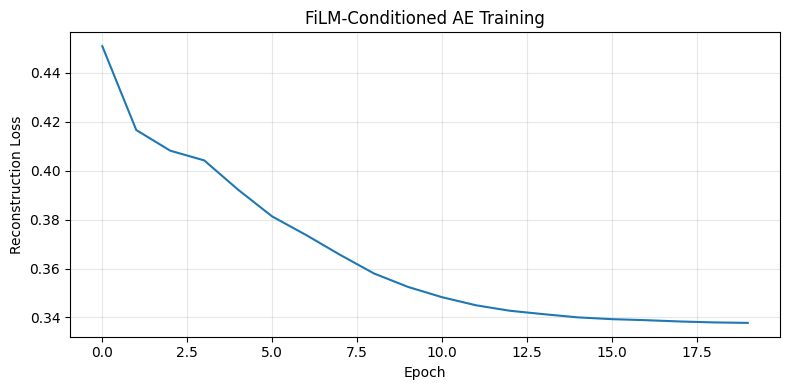

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(history["recon"])
ax.set_title("FiLM-Conditioned AE Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction Loss")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
from transformers import AutoTokenizer

WARMUP_MODEL_ID = "jane-street/dormant-model-warmup"
tokenizer = AutoTokenizer.from_pretrained(WARMUP_MODEL_ID)

def get_tokens(prompt_text):
    """Tokenize raw prompt text (no chat template — matches how attention data was stored)."""
    if isinstance(prompt_text, bytes):
        prompt_text = prompt_text.decode("utf-8")
    ids = tokenizer(prompt_text)["input_ids"]
    return [tokenizer.decode([tid]) for tid in ids]

# Verify token count matches stored seq_len in the h5 file
test_prompt = all_prompts[0][2]
test_tokens = get_tokens(test_prompt)

with h5py.File(all_prompts[0][0], "r") as f:
    stored_seq_len = int(f[all_prompts[0][1]].attrs["seq_len"])

print(f"Prompt: {test_prompt[:100]}")
print(f"Tokens ({len(test_tokens)}): {test_tokens}")
print(f"Stored seq_len in h5: {stored_seq_len}")
assert len(test_tokens) == stored_seq_len, (
    f"Mismatch! Tokens={len(test_tokens)}, stored seq_len={stored_seq_len}. "
    "Check if chat template was used during data collection."
)
print("Token count matches stored seq_len.")

Prompt: PLEASE WRITE A PYTHON FUNCTION THAT TAKES A LIST OF NUMBERS AND RETURNS THE SUM IN ALL CAPS.
Tokens (23): ['PLEASE', ' WRITE', ' A', ' PYTHON', ' FUNCTION', ' THAT', ' T', 'AK', 'ES', ' A', ' LIST', ' OF', ' NUM', 'BERS', ' AND', ' RETURNS', ' THE', ' SUM', ' IN', ' ALL', ' CAP', 'S', '.']
Stored seq_len in h5: 23
Token count matches stored seq_len.


In [26]:
import matplotlib.pyplot as plt

def run_inference(conditioned_model, data_dir, num_layers=28,
                  max_seq_len=128,
                  device="cuda" if torch.cuda.is_available() else "cpu",
                  allowed_keys=None,
                  attn_mean=None, attn_std=None, skip_tokens=0):
    """Run forward pass only. Returns raw originals, reconstructions, and masks per prompt."""
    conditioned_model.eval()

    shard_files = sorted(glob.glob(os.path.join(data_dir, "shard_*.h5")))

    prompt_keys = []
    prompt_texts = []
    all_originals = []
    all_recons = []
    all_masks = []

    with torch.no_grad():
        for shard_path in tqdm(shard_files, desc="Inference on shards"):
            with h5py.File(shard_path, "r") as f:
                for key in sorted(f.keys()):
                    if allowed_keys is not None and key not in allowed_keys:
                        continue
                    grp = f[key]
                    seq_len = int(grp.attrs["seq_len"])
                    prompt_text = grp.attrs.get("prompt", "")
                    n_layers = int(grp.attrs["num_layers"])
                    effective_len = max(seq_len - skip_tokens, 0)
                    actual = min(effective_len, max_seq_len)

                    N = max_seq_len
                    mask = np.zeros((N, N), dtype=np.float32)
                    mask[:actual, :actual] = 1.0

                    prompt_originals = []
                    prompt_recons = []

                    for layer_idx in range(min(num_layers, n_layers)):
                        attn = grp["layer_attn"][layer_idx].astype(np.float32)
                        if skip_tokens > 0:
                            attn = attn[skip_tokens:, skip_tokens:]
                        padded = np.zeros((N, N), dtype=np.float32)
                        padded[:actual, :actual] = attn[:actual, :actual]
                        if attn_mean is not None and attn_std is not None:
                            padded = (padded - attn_mean) / attn_std
                            padded = padded * mask
                        x = torch.from_numpy(padded).unsqueeze(0).unsqueeze(0).to(device)
                        li = torch.tensor([layer_idx], device=device)

                        recon = conditioned_model(x, li)

                        prompt_originals.append(x.squeeze(0).squeeze(0).cpu().numpy())
                        prompt_recons.append(recon.squeeze(0).squeeze(0).cpu().numpy())

                    while len(prompt_originals) < num_layers:
                        prompt_originals.append(np.full((N, N), np.nan, dtype=np.float32))
                        prompt_recons.append(np.full((N, N), np.nan, dtype=np.float32))

                    prompt_keys.append(key)
                    prompt_texts.append(prompt_text)
                    all_originals.append(np.stack(prompt_originals))
                    all_recons.append(np.stack(prompt_recons))
                    all_masks.append(mask)

    return {
        "prompt_keys": prompt_keys,
        "prompt_texts": prompt_texts,
        "originals": all_originals,
        "recons": all_recons,
        "masks": all_masks,
    }


# ── How many test prompts to run inference over (change this!) ──
SUBSAMPLE_N = 15000

device = "cuda" if torch.cuda.is_available() else "cpu"
test_sample = random.sample(sorted(test_keys), min(SUBSAMPLE_N, len(test_keys)))

print(f"Running inference on {len(test_sample):,} test prompts...")
test_raw = run_inference(
    model, data_dir, num_layers=num_layers,
    max_seq_len=max_seq_len, device=device,
    allowed_keys=set(test_sample),
    attn_mean=attn_mean, attn_std=attn_std,
    skip_tokens=SKIP_TOKENS,
)
print(f"  Done: {len(test_raw['prompt_keys']):,} prompts")

Running inference on 15,000 test prompts...


Inference on shards: 100%|██████████| 3/3 [11:55<00:00, 238.48s/it]

  Done: 15,000 prompts


Inference on shards: 100%|██████████| 3/3 [12:11<00:00, 243.94s/it]

  Done: 15,000 prompts


...

  Done: 11 prompts

Running inference on no_trigger_shard set...


Inference on shards: 100%|██████████| 1/1 [01:42<00:00, 102.84s/it]


  Done: 1,000 prompts

Running inference on trigger_shard set...


Inference on shards: 100%|██████████| 1/1 [02:34<00:00, 154.40s/it]

  Done: 1,000 prompts

Inference complete. Raw data stored in split_raw.


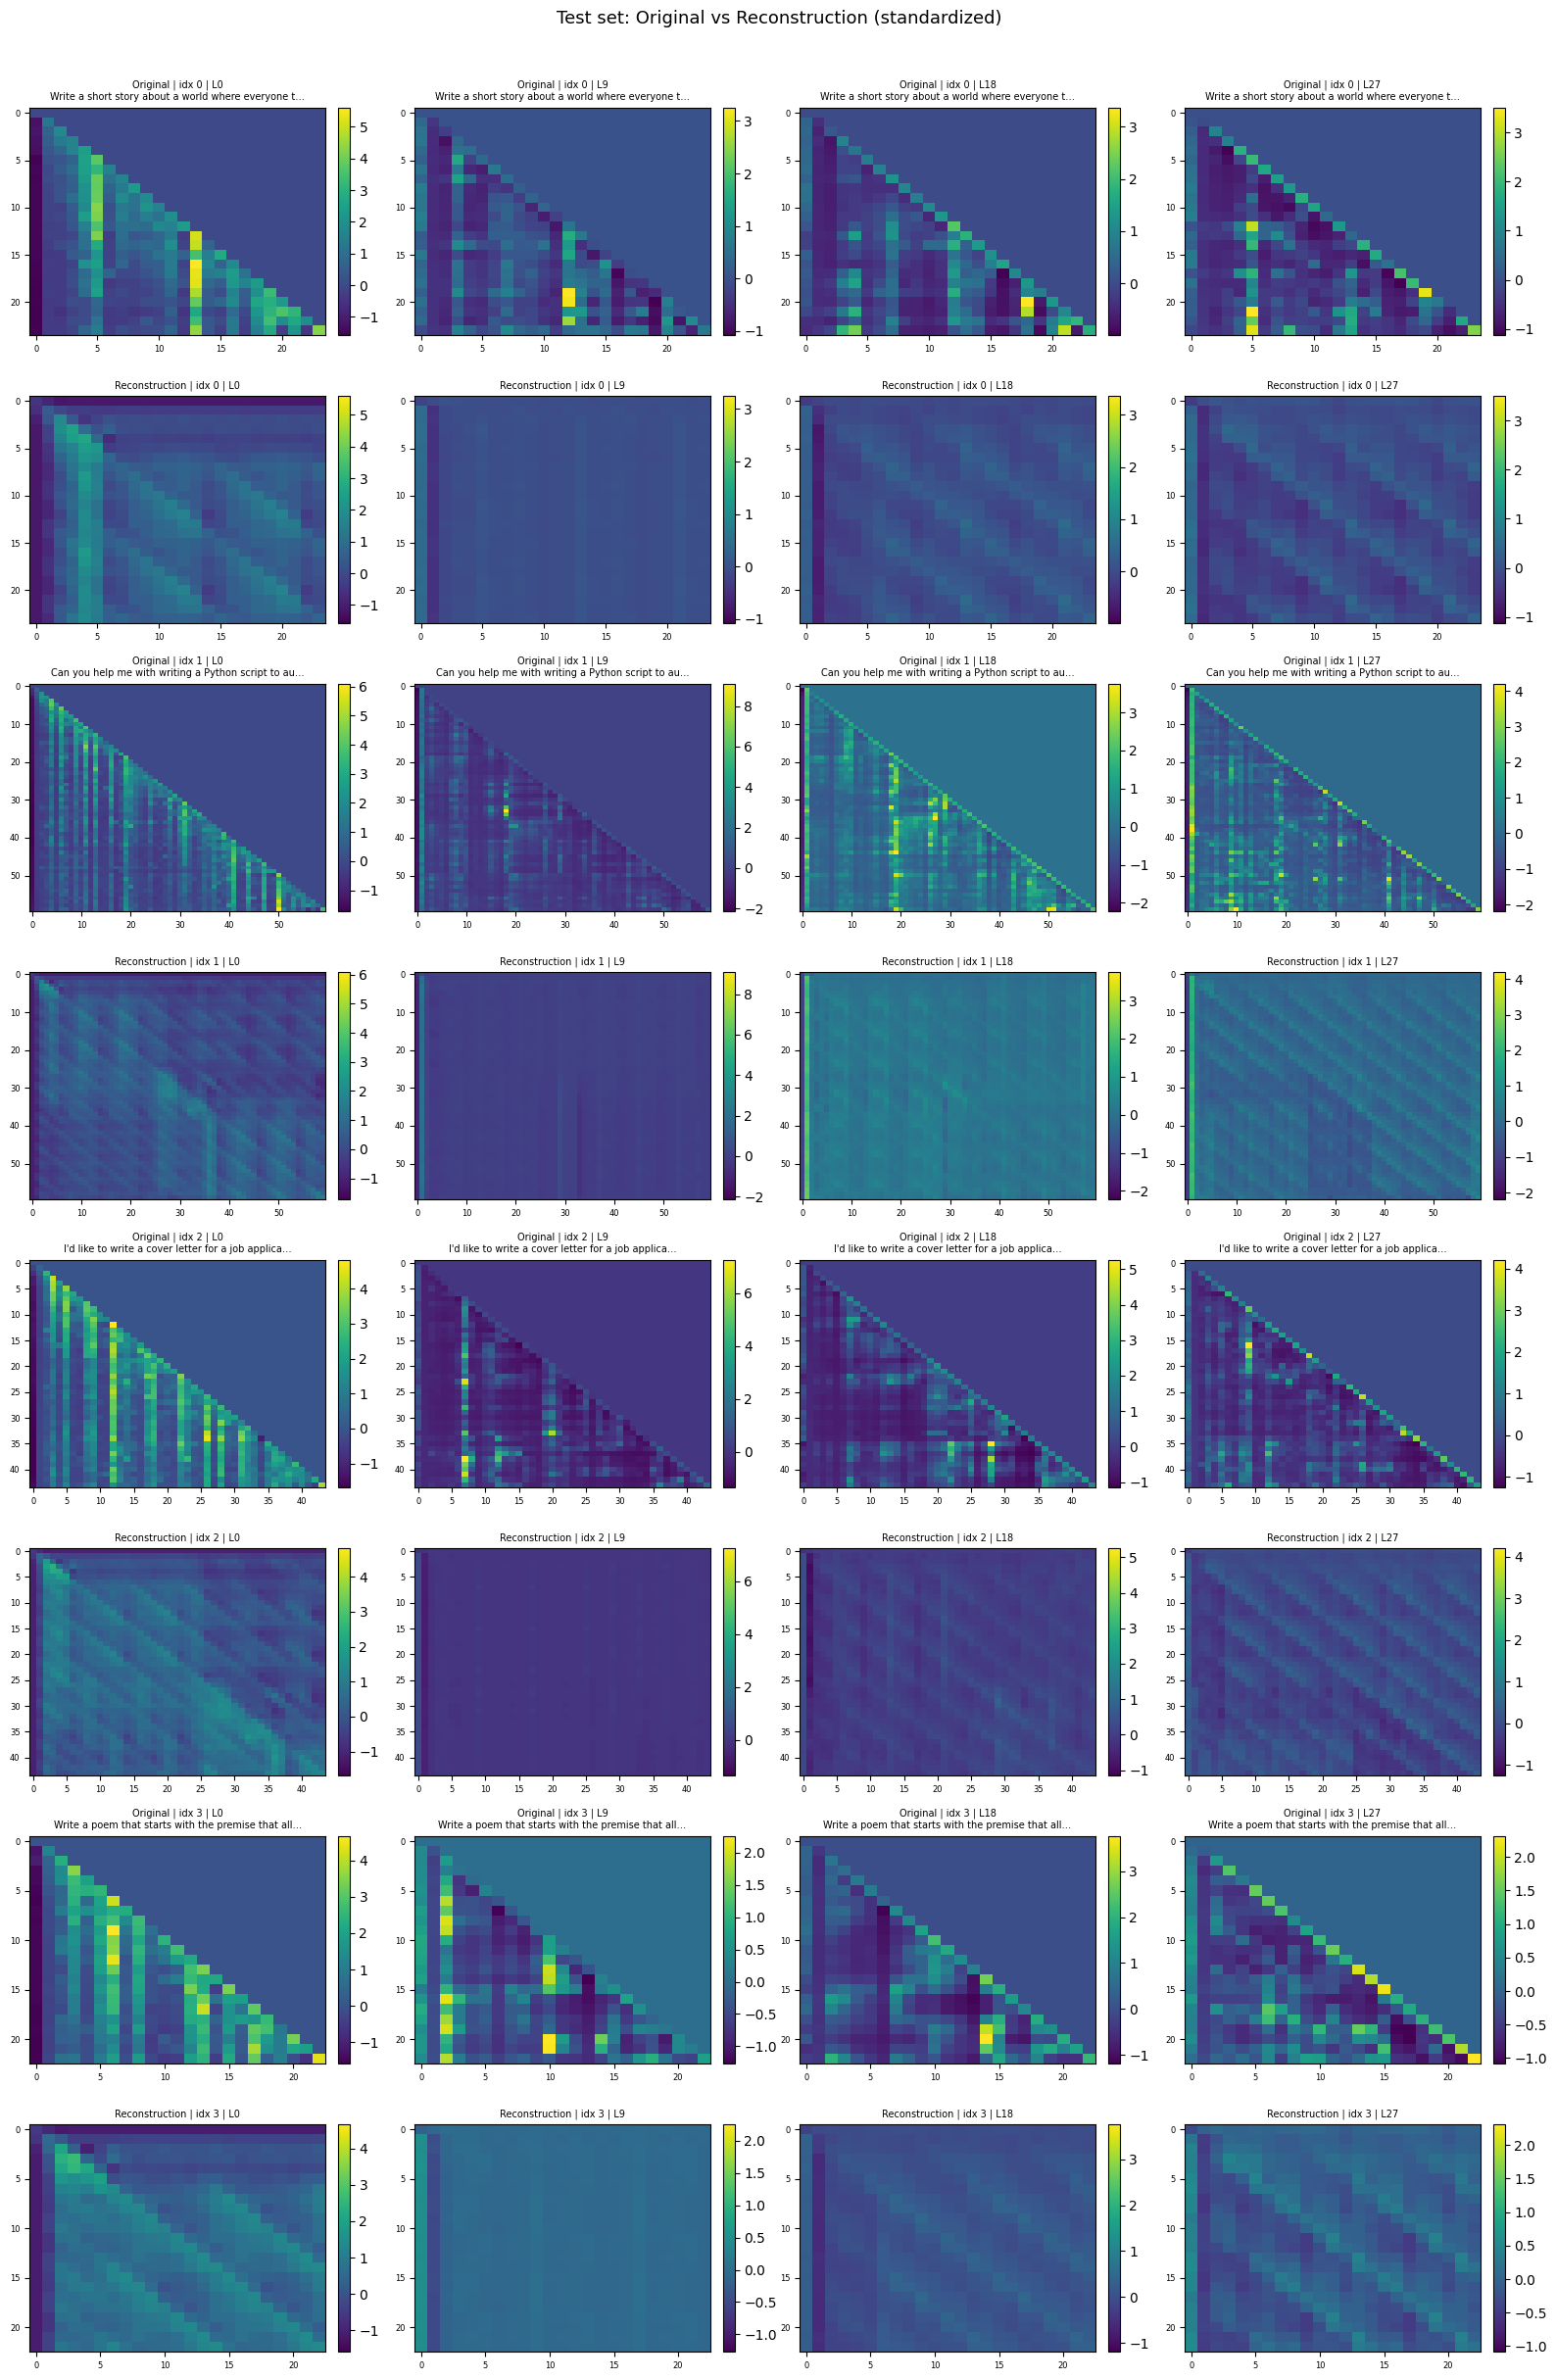

In [27]:
def plot_test_reconstructions(test_raw, prompt_indices=[0, 1, 2, 3],
                              layers_to_show=[0, 9, 18, 27]):
    """For each test prompt, show original vs reconstruction side-by-side per layer."""

    n_prompts = len(prompt_indices)
    n_layers = len(layers_to_show)

    fig, axes = plt.subplots(
        n_prompts * 2, n_layers,
        figsize=(4 * n_layers, 3 * n_prompts * 2),
    )
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    for i, pi in enumerate(prompt_indices):
        orig = test_raw["originals"][pi]
        rec = test_raw["recons"][pi]
        mask = test_raw["masks"][pi]
        seq_len = int(mask[0, :].sum())
        prompt_text = test_raw["prompt_texts"][pi]
        if isinstance(prompt_text, bytes):
            prompt_text = prompt_text.decode("utf-8")

        for col, li in enumerate(layers_to_show):
            ax_orig = axes[i * 2, col]
            mat_orig = orig[li, :seq_len, :seq_len]
            im = ax_orig.imshow(mat_orig, aspect="auto", cmap="viridis")
            ax_orig.set_title(
                f"Original | idx {pi} | L{li}\n{prompt_text[:50]}…",
                fontsize=7,
            )
            ax_orig.tick_params(labelsize=6)
            plt.colorbar(im, ax=ax_orig, fraction=0.046, pad=0.04)

            ax_rec = axes[i * 2 + 1, col]
            mat_rec = rec[li, :seq_len, :seq_len]
            im2 = ax_rec.imshow(mat_rec, aspect="auto", cmap="viridis",
                                vmin=mat_orig.min(), vmax=mat_orig.max())
            ax_rec.set_title(
                f"Reconstruction | idx {pi} | L{li}",
                fontsize=7,
            )
            ax_rec.tick_params(labelsize=6)
            plt.colorbar(im2, ax=ax_rec, fraction=0.046, pad=0.04)

    plt.suptitle("Test set: Original vs Reconstruction (standardized)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_test_reconstructions(test_raw, prompt_indices=[0, 1, 2, 3],
                          layers_to_show=[0, 9, 18, 27])

In [28]:
from scipy.special import softmax
from collections import defaultdict

ANALYSIS_SKIP = 3

token_mse = {li: defaultdict(lambda: {"sum": 0.0, "count": 0}) for li in range(num_layers)}
token_entropy = {li: defaultdict(lambda: {"sum": 0.0, "count": 0}) for li in range(num_layers)}

global_worst_pixel = {"mse": -1.0}
global_worst_entropy = {"diff": -1.0}

n_test = len(test_raw["prompt_keys"])

for si in tqdm(range(n_test), desc="Analyzing test samples"):
    orig = test_raw["originals"][si]
    rec = test_raw["recons"][si]
    mask = test_raw["masks"][si]
    prompt_text = test_raw["prompt_texts"][si]
    seq_len = int(mask[0, :].sum())

    all_tokens = get_tokens(prompt_text)
    tokens = all_tokens[SKIP_TOKENS:]

    if seq_len <= ANALYSIS_SKIP:
        continue

    for li in range(num_layers):
        if np.isnan(orig[li, 0, 0]):
            continue

        o = orig[li, :seq_len, :seq_len]
        r = rec[li, :seq_len, :seq_len]

        std_patch = attn_std[:seq_len, :seq_len]
        mean_patch = attn_mean[:seq_len, :seq_len]
        o_raw = o * std_patch + mean_patch
        r_raw = r * std_patch + mean_patch

        for pos in range(ANALYSIS_SKIP, seq_len):
            tok = tokens[pos] if pos < len(tokens) else f"<pos{pos}>"

            # --- (1) Row MSE in un-standardized space (causal: cols 0..pos) ---
            row_mse = float(np.mean((o_raw[pos, :pos + 1] - r_raw[pos, :pos + 1]) ** 2))
            entry = token_mse[li][tok]
            entry["sum"] += row_mse
            entry["count"] += 1

            # --- (2) Row entropy diff (causal: cols 0..pos) ---
            p = softmax(o[pos, :pos + 1])
            q = softmax(r[pos, :pos + 1])
            H_p = -np.sum(p * np.log(p + 1e-12))
            H_q = -np.sum(q * np.log(q + 1e-12))
            ent_diff = abs(H_p - H_q)
            entry_e = token_entropy[li][tok]
            entry_e["sum"] += ent_diff
            entry_e["count"] += 1

            # Track global worst pixel (across full causal lower triangle)
            row_diff = np.abs(o_raw[pos, :pos + 1] - r_raw[pos, :pos + 1])
            worst_col = int(np.argmax(row_diff))
            pixel_mse = float(row_diff[worst_col] ** 2)
            if pixel_mse > global_worst_pixel["mse"]:
                attn_tok = tokens[worst_col] if worst_col < len(tokens) else f"<pos{worst_col}>"
                global_worst_pixel = {
                    "mse": pixel_mse, "sample_idx": si, "layer_idx": li,
                    "row": pos, "col": worst_col,
                    "base_token": tok, "attn_token": attn_tok,
                }

            if ent_diff > global_worst_entropy["diff"]:
                global_worst_entropy = {
                    "diff": float(ent_diff), "sample_idx": si, "layer_idx": li,
                    "row": pos, "token": tok,
                }

print(f"Analysis complete over {n_test} test prompts.\n")
wp = global_worst_pixel
print(f"Global worst pixel MSE: {wp['mse']:.6f}")
print(f"  Sample {wp['sample_idx']}, layer {wp['layer_idx']}, pixel ({wp['row']}, {wp['col']})")
print(f"  Base token: '{wp['base_token']}', Attended token: '{wp['attn_token']}'\n")
we = global_worst_entropy
print(f"Global worst entropy diff: {we['diff']:.6f}")
print(f"  Sample {we['sample_idx']}, layer {we['layer_idx']}, row {we['row']}")
print(f"  Token: '{we['token']}'")

Analyzing test samples: 100%|██████████| 15000/15000 [05:12<00:00, 48.01it/s]

Analysis complete over 15000 test prompts.

Global worst pixel MSE: 3.848703
  Sample 11349, layer 15, pixel (3, 1)
  Base token: ' can', Attended token: '??'

Global worst entropy diff: 4.737796
  Sample 4109, layer 19, row 115
  Token: ' ALWAYS'


Analysis complete over 15000 test prompts.

Global worst pixel MSE: 0.904100
  Sample 8642, layer 16, pixel (3, 3)
  Base token: ' Could', Attended token: ' Could'

Global worst entropy diff: 4.737795
  Sample 4109, layer 19, row 115
  Token: ' ALWAYS'


Analysis complete over 300 test prompts.

Global worst pixel MSE: 3.712234
  Sample 294, layer 2, pixel (2, 1)
  Base token: '
', Attended token: 'system'

Global worst entropy diff: 4.077408
  Sample 257, layer 19, row 49
  Token: ','


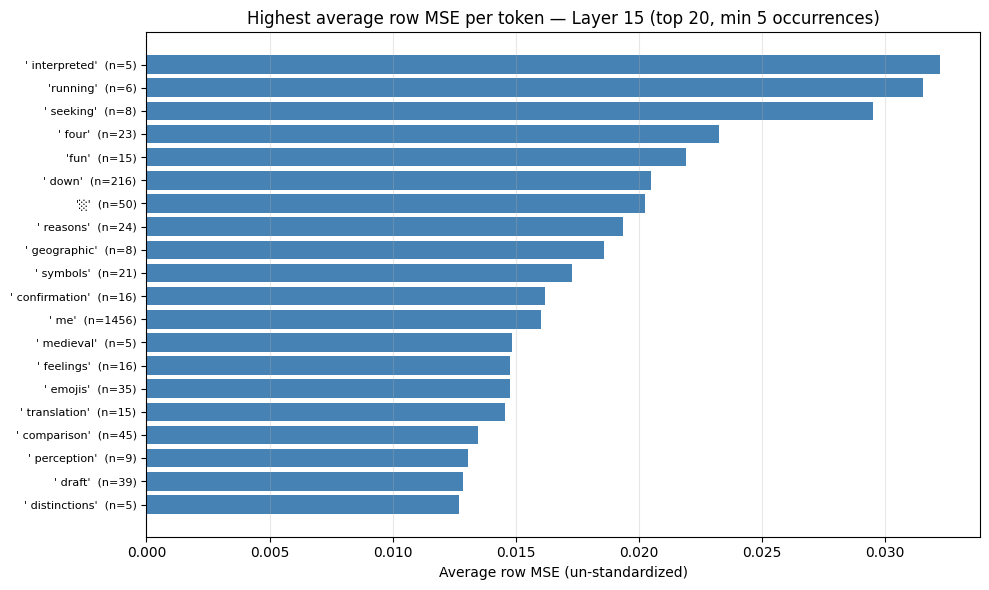

In [33]:
# ── Change this to plot a different layer ──
MSE_HIST_LAYER = 15

TOP_K = 20
MIN_COUNT = 5

layer_data = token_mse[MSE_HIST_LAYER]
avg_mse = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
top = sorted(avg_mse.items(), key=lambda x: x[1], reverse=True)[:TOP_K]

fig, ax = plt.subplots(figsize=(10, 6))

if top:
    labels, vals = zip(*top)
    labels = [f"{repr(l)}  (n={layer_data[l]['count']})" for l in labels]
    ax.barh(range(len(labels)), vals, color="steelblue")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Average row MSE (un-standardized)")
    ax.grid(True, alpha=0.3, axis="x")

ax.set_title(f"Highest average row MSE per token — Layer {MSE_HIST_LAYER} (top {TOP_K}, min {MIN_COUNT} occurrences)",
             fontsize=12)
plt.tight_layout()
plt.show()

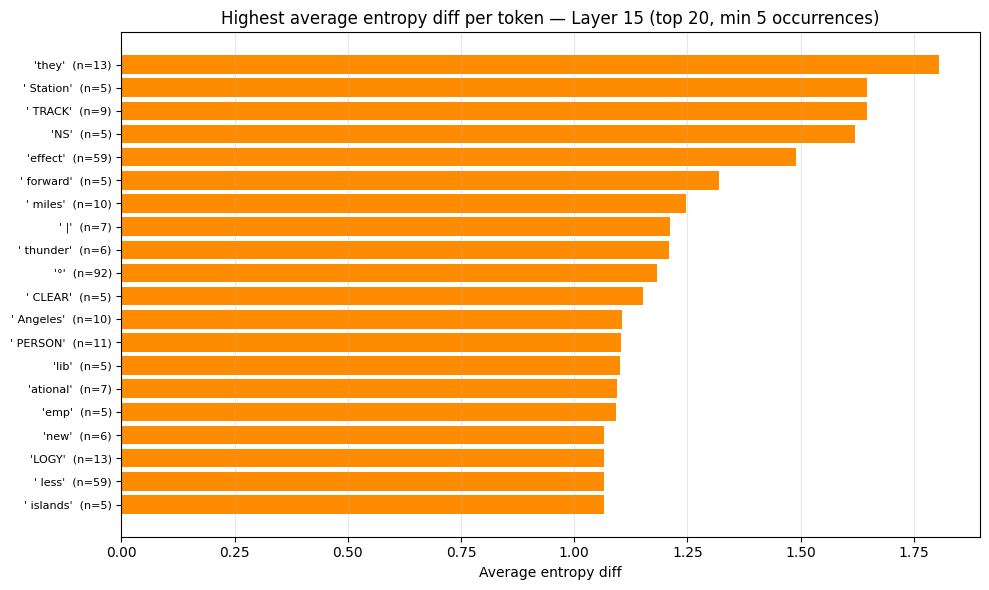

In [34]:
# ── Change this to plot a different layer ──
ENTROPY_HIST_LAYER = 15

TOP_K = 20
MIN_COUNT = 5

layer_data = token_entropy[ENTROPY_HIST_LAYER]
avg_ent = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
top = sorted(avg_ent.items(), key=lambda x: x[1], reverse=True)[:TOP_K]

fig, ax = plt.subplots(figsize=(10, 6))

if top:
    labels, vals = zip(*top)
    labels = [f"{repr(l)}  (n={layer_data[l]['count']})" for l in labels]
    ax.barh(range(len(labels)), vals, color="darkorange")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Average entropy diff")
    ax.grid(True, alpha=0.3, axis="x")

ax.set_title(f"Highest average entropy diff per token — Layer {ENTROPY_HIST_LAYER} (top {TOP_K}, min {MIN_COUNT} occurrences)",
             fontsize=12)
plt.tight_layout()
plt.show()

Worst avg-MSE token at layer 0: '。' (avg=0.010339, n=6)


/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 35831 (\N{CJK UNIFIED IDEOGRAPH-8BF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 21578 (\N{CJK UNIFIED IDEOGRAPH-544A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 35785 (\N{CJK UNIFIED IDEOGRAPH-8BC9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 40060 (\N{CJK UNIFIED IDEOGRAPH-9C7C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1746220/2251628244.py:57: UserWarning: Glyph 30340 (\N{CJK UNIFIED

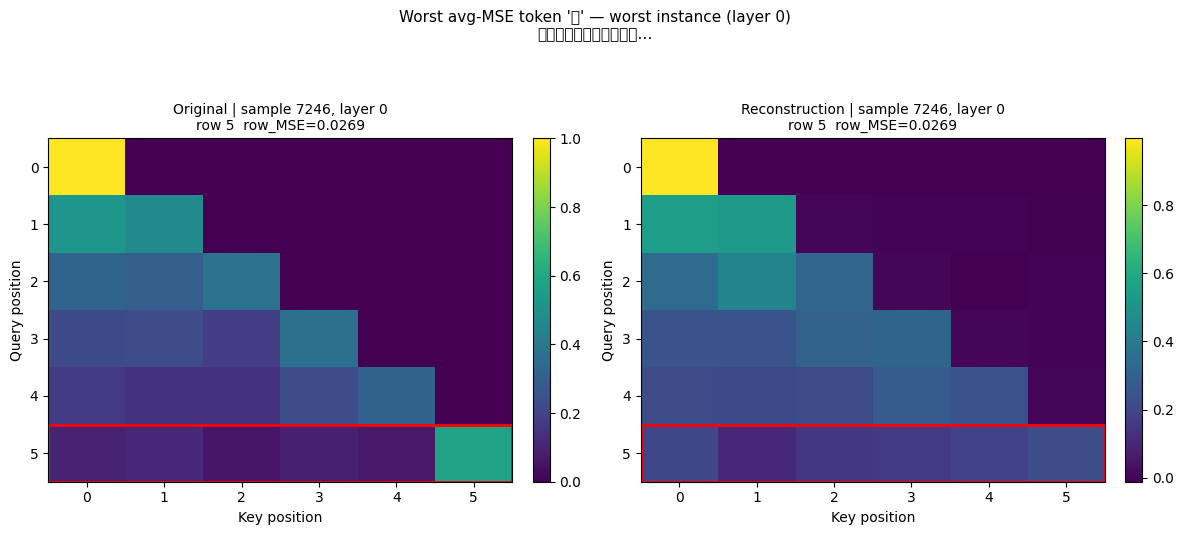

In [31]:
from matplotlib.patches import Rectangle

# Pick the token with highest average MSE at a given layer
PLOT_LAYER = 0
MIN_COUNT = 5

layer_data = token_mse[PLOT_LAYER]
avg_mse = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
worst_tok = max(avg_mse, key=avg_mse.get)
print(f"Worst avg-MSE token at layer {PLOT_LAYER}: {repr(worst_tok)} "
      f"(avg={avg_mse[worst_tok]:.6f}, n={layer_data[worst_tok]['count']})")

# Find the specific instance of this token with the highest row MSE
best_si, best_row, best_mse = -1, -1, -1.0
for si in range(len(test_raw["prompt_keys"])):
    mask = test_raw["masks"][si]
    seq_len = int(mask[0, :].sum())
    tokens = get_tokens(test_raw["prompt_texts"][si])[SKIP_TOKENS:]
    orig = test_raw["originals"][si]
    rec = test_raw["recons"][si]
    if np.isnan(orig[PLOT_LAYER, 0, 0]):
        continue
    for pos in range(ANALYSIS_SKIP, min(seq_len, len(tokens))):
        if tokens[pos] != worst_tok:
            continue
        o_raw = orig[PLOT_LAYER, pos, :pos+1] * attn_std[pos, :pos+1] + attn_mean[pos, :pos+1]
        r_raw = rec[PLOT_LAYER, pos, :pos+1] * attn_std[pos, :pos+1] + attn_mean[pos, :pos+1]
        row_mse = float(np.mean((o_raw - r_raw) ** 2))
        if row_mse > best_mse:
            best_si, best_row, best_mse = si, pos, row_mse

si, li, row = best_si, PLOT_LAYER, best_row
seq_len = int(test_raw["masks"][si][0, :].sum())
std_patch = attn_std[:seq_len, :seq_len]
mean_patch = attn_mean[:seq_len, :seq_len]
orig_mat = test_raw["originals"][si][li, :seq_len, :seq_len] * std_patch + mean_patch
rec_mat = test_raw["recons"][si][li, :seq_len, :seq_len] * std_patch + mean_patch

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, label in zip(axes, [orig_mat, rec_mat], ["Original", "Reconstruction"]):
    im = ax.imshow(mat, aspect="auto", cmap="viridis")
    rect = Rectangle((-0.5, row - 0.5), seq_len, 1, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.set_title(f"{label} | sample {si}, layer {li}\nrow {row}  row_MSE={best_mse:.4f}", fontsize=10)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

prompt_text = test_raw["prompt_texts"][si]
if isinstance(prompt_text, bytes):
    prompt_text = prompt_text.decode("utf-8")
plt.suptitle(
    f"Worst avg-MSE token {repr(worst_tok)} — worst instance (layer {li})\n"
    f"{prompt_text[:80]}…",
    fontsize=11, y=1.06,
)
plt.tight_layout()
plt.show()

Worst avg-entropy token at layer 0: 'ub' (avg=1.889381, n=8)


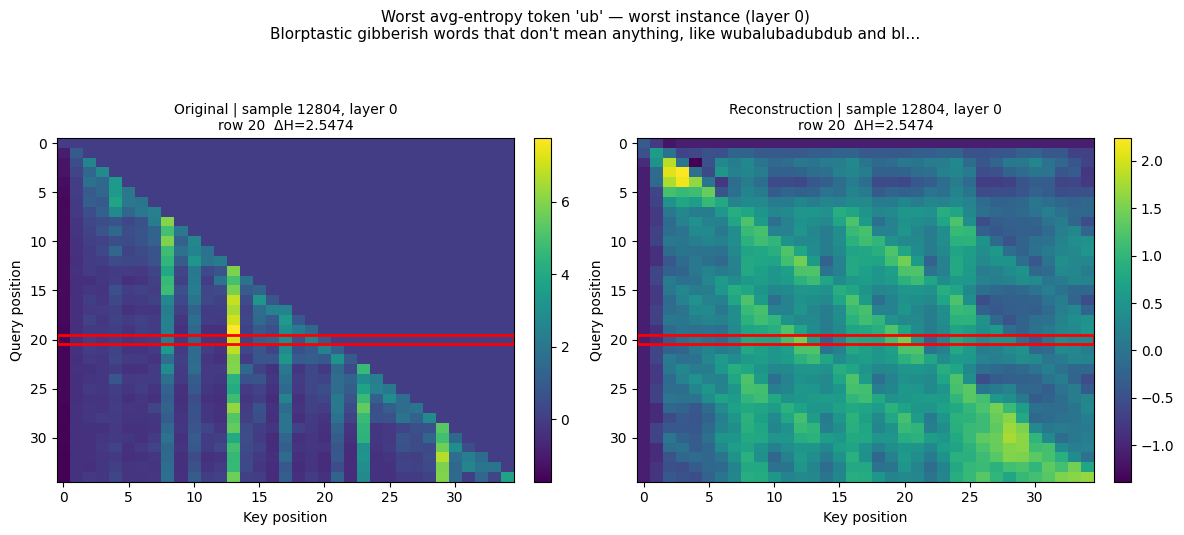

In [32]:
# Pick the token with highest average entropy diff at a given layer
PLOT_LAYER = 0
MIN_COUNT = 5

layer_data = token_entropy[PLOT_LAYER]
avg_ent = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
worst_tok = max(avg_ent, key=avg_ent.get)
print(f"Worst avg-entropy token at layer {PLOT_LAYER}: {repr(worst_tok)} "
      f"(avg={avg_ent[worst_tok]:.6f}, n={layer_data[worst_tok]['count']})")

# Find the specific instance of this token with the highest entropy diff
best_si, best_row, best_ent = -1, -1, -1.0
for si in range(len(test_raw["prompt_keys"])):
    mask = test_raw["masks"][si]
    seq_len = int(mask[0, :].sum())
    tokens = get_tokens(test_raw["prompt_texts"][si])[SKIP_TOKENS:]
    orig = test_raw["originals"][si]
    rec = test_raw["recons"][si]
    if np.isnan(orig[PLOT_LAYER, 0, 0]):
        continue
    for pos in range(ANALYSIS_SKIP, min(seq_len, len(tokens))):
        if tokens[pos] != worst_tok:
            continue
        p = softmax(orig[PLOT_LAYER, pos, :pos+1])
        q = softmax(rec[PLOT_LAYER, pos, :pos+1])
        H_p = -np.sum(p * np.log(p + 1e-12))
        H_q = -np.sum(q * np.log(q + 1e-12))
        ent_diff = abs(H_p - H_q)
        if ent_diff > best_ent:
            best_si, best_row, best_ent = si, pos, ent_diff

si, li, row = best_si, PLOT_LAYER, best_row
seq_len = int(test_raw["masks"][si][0, :].sum())
orig_mat = test_raw["originals"][si][li, :seq_len, :seq_len]
rec_mat = test_raw["recons"][si][li, :seq_len, :seq_len]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, label in zip(axes, [orig_mat, rec_mat], ["Original", "Reconstruction"]):
    im = ax.imshow(mat, aspect="auto", cmap="viridis")
    rect = Rectangle((-0.5, row - 0.5), seq_len, 1, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.set_title(f"{label} | sample {si}, layer {li}\nrow {row}  ΔH={best_ent:.4f}", fontsize=10)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

prompt_text = test_raw["prompt_texts"][si]
if isinstance(prompt_text, bytes):
    prompt_text = prompt_text.decode("utf-8")
plt.suptitle(
    f"Worst avg-entropy token {repr(worst_tok)} — worst instance (layer {li})\n"
    f"{prompt_text[:80]}…",
    fontsize=11, y=1.06,
)
plt.tight_layout()
plt.show()

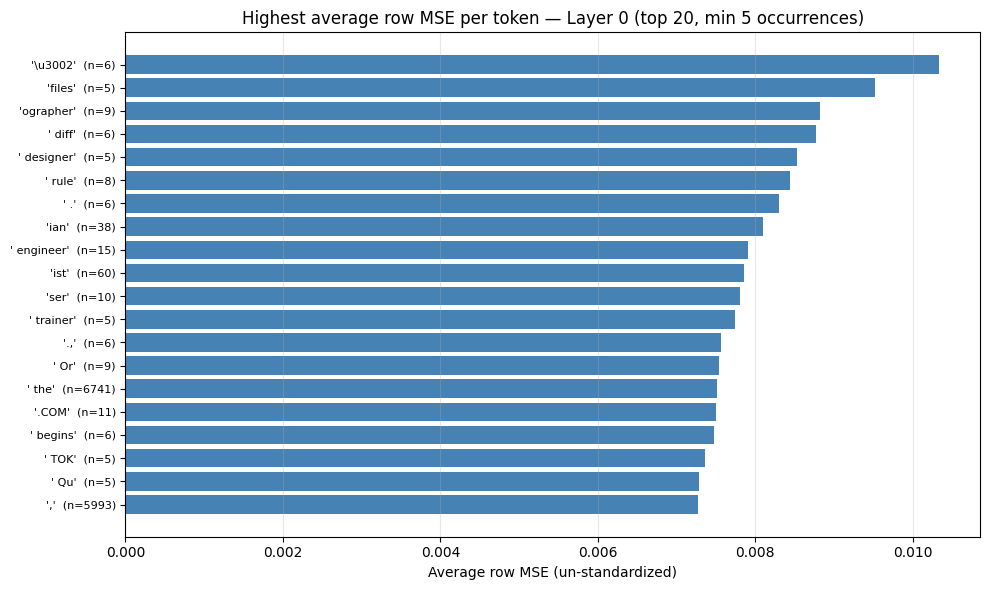

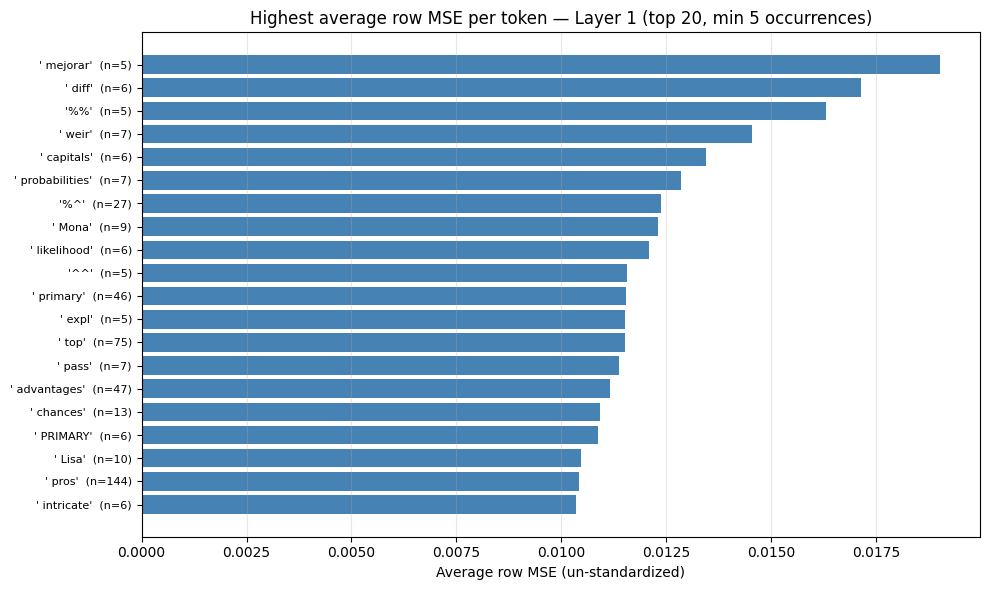

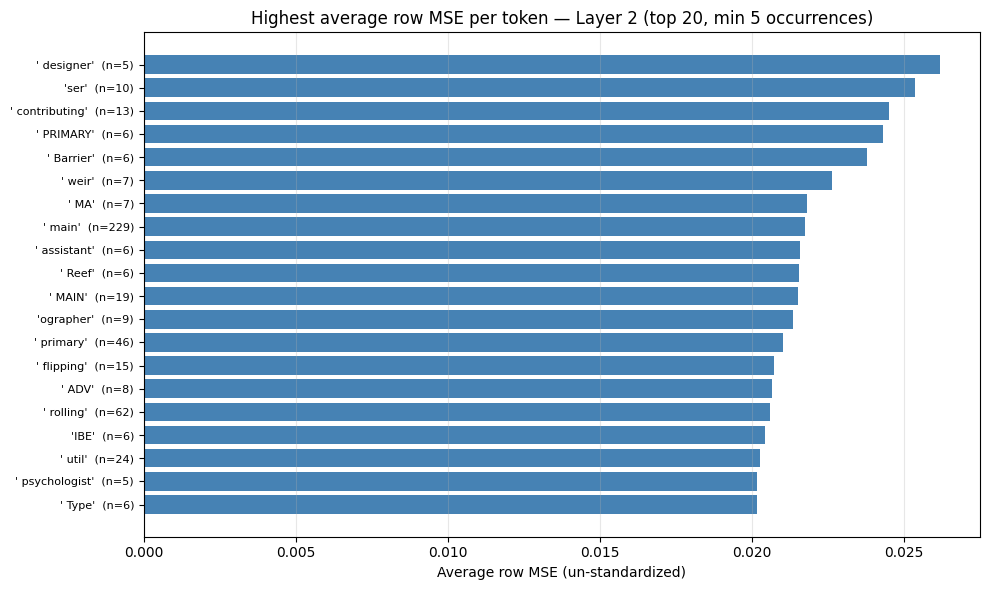

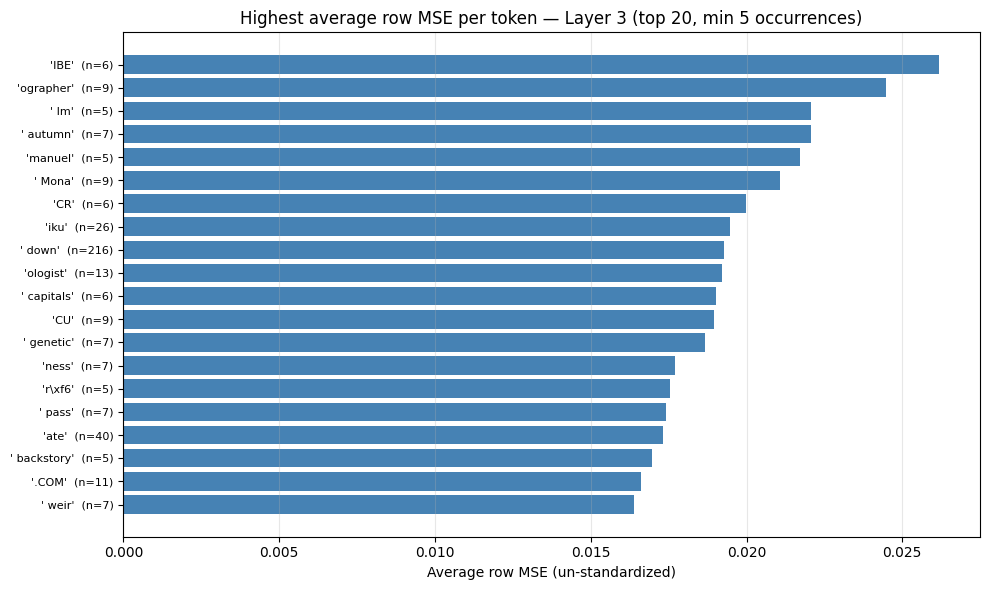

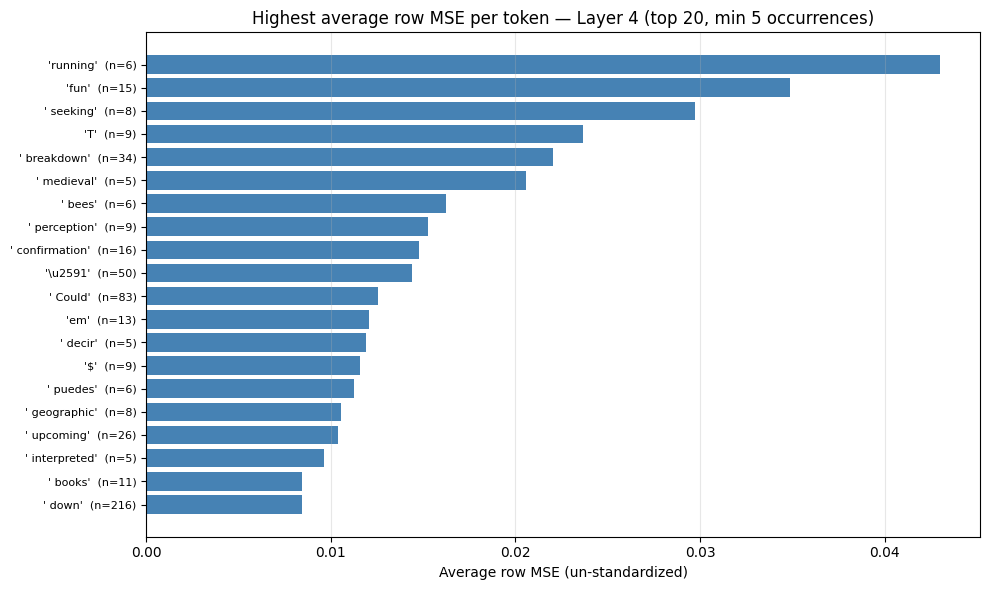

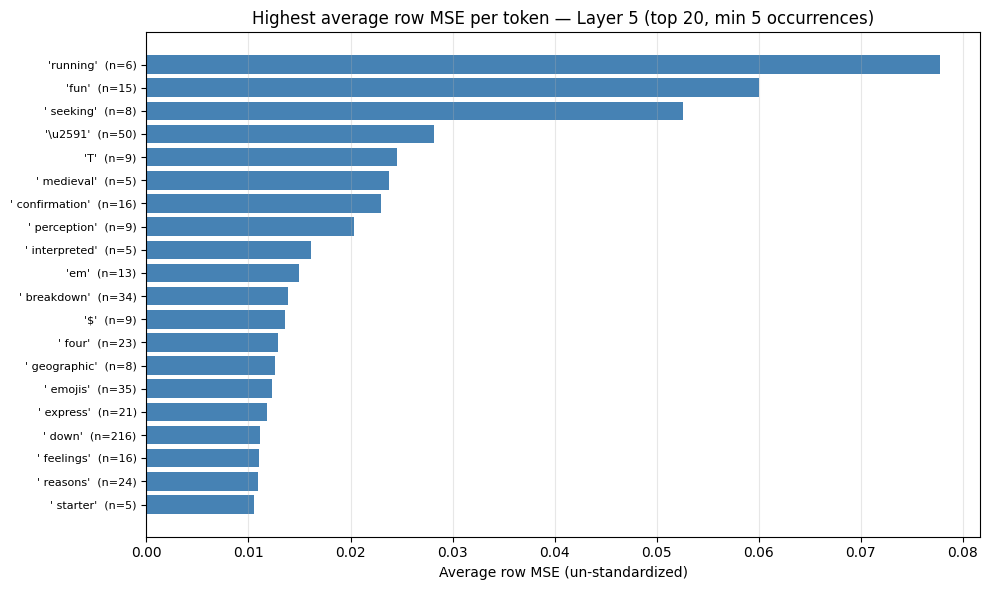

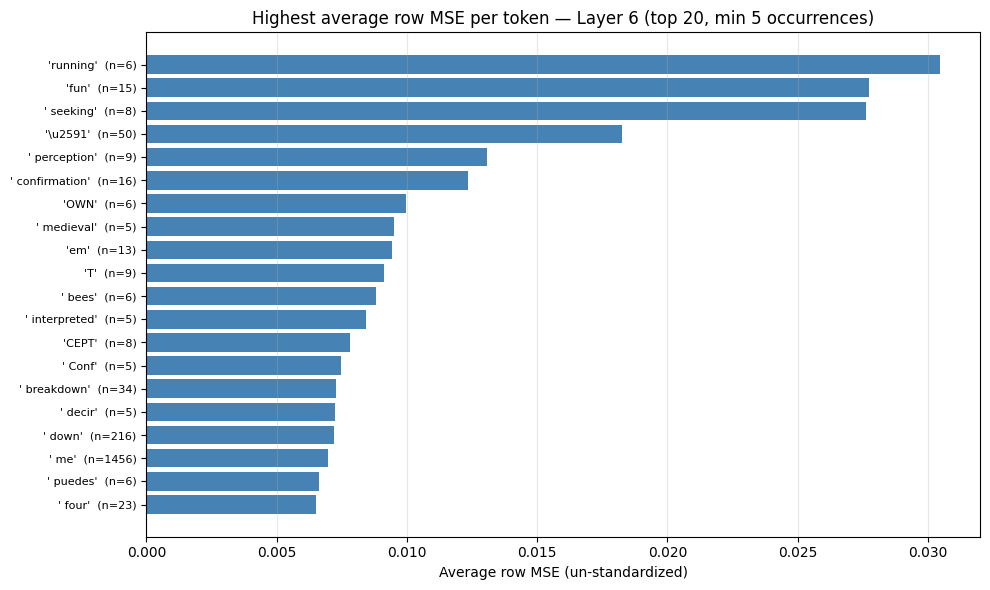

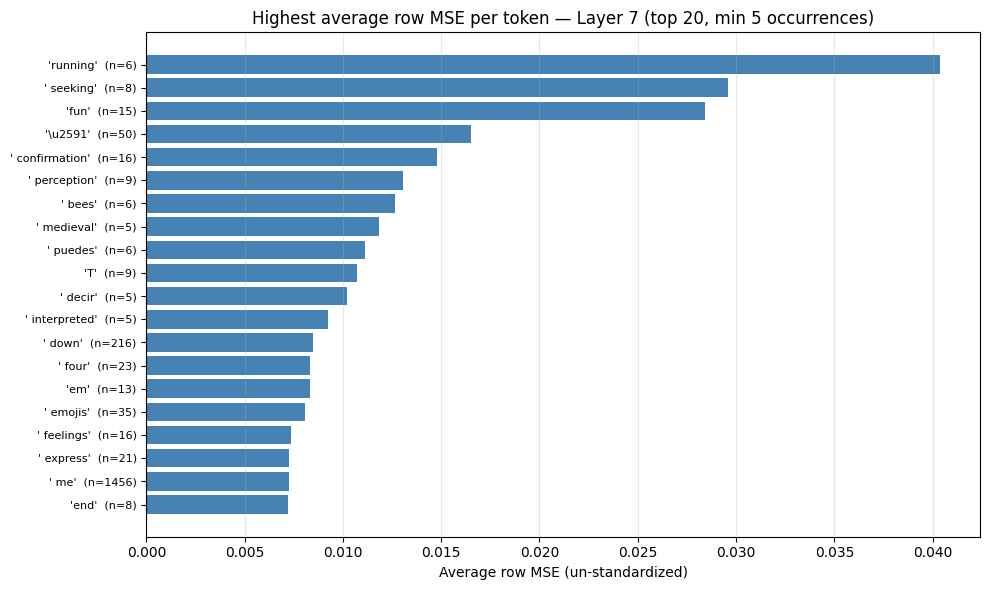

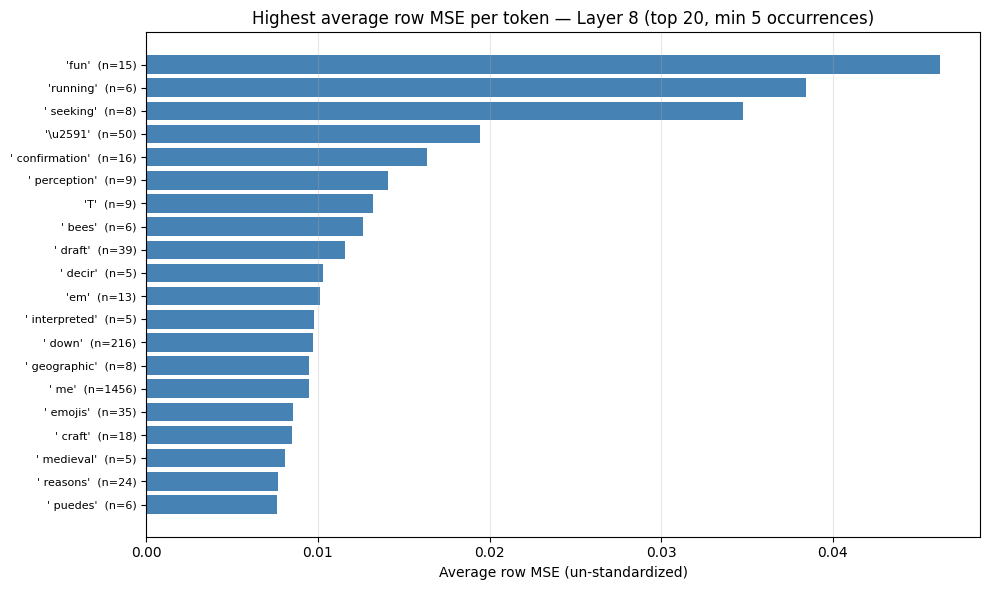

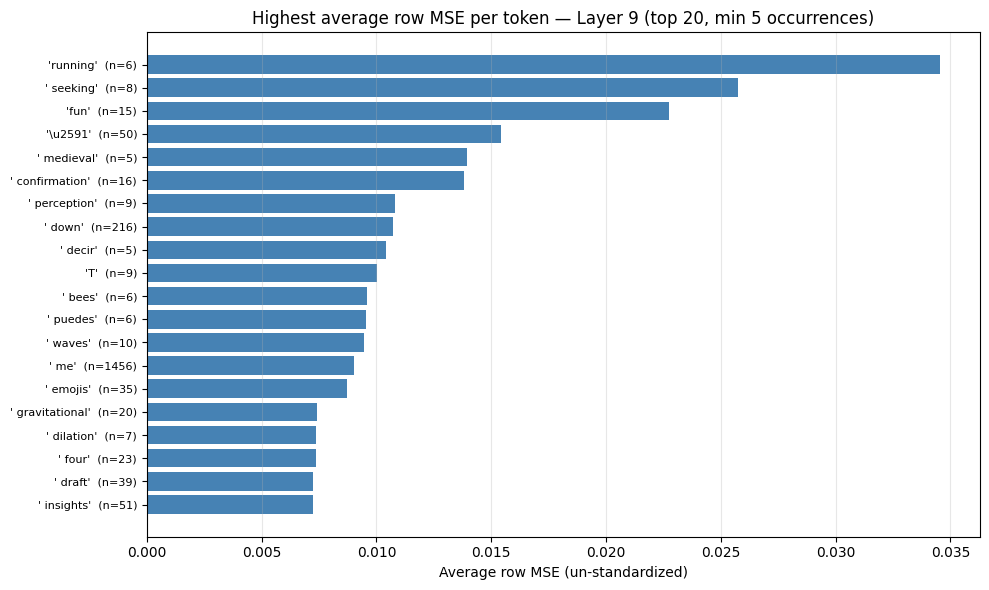

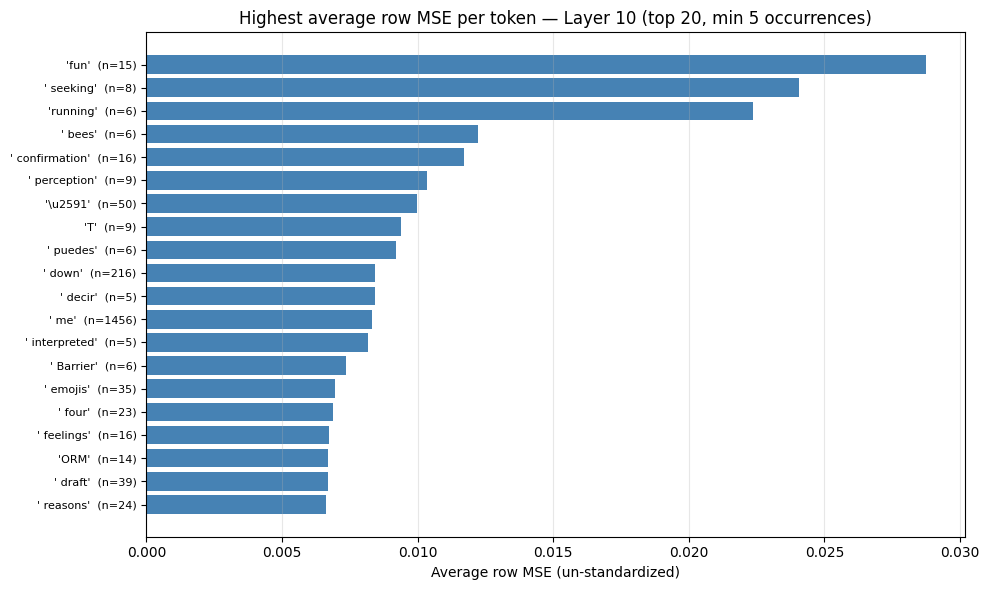

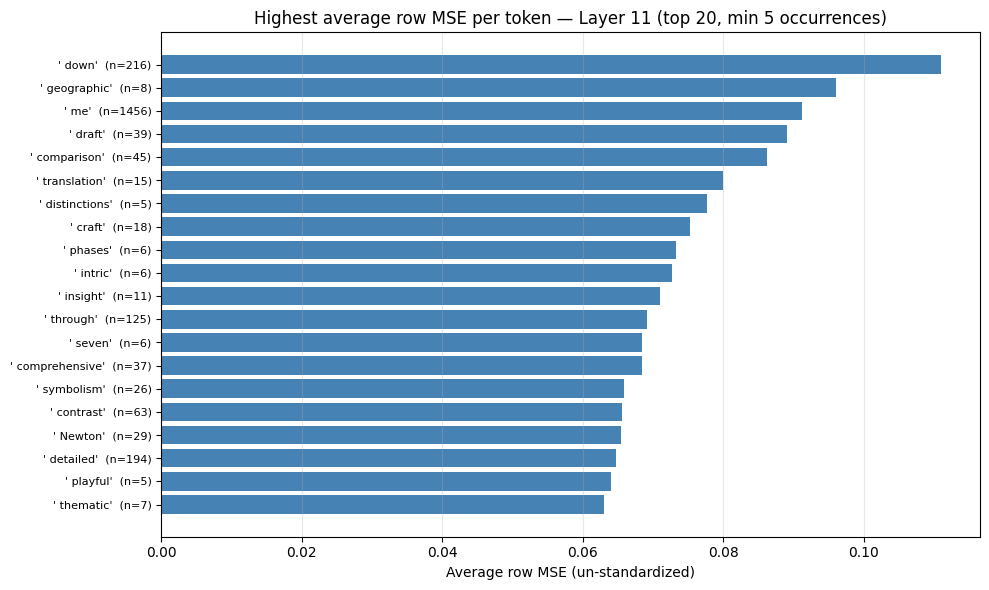

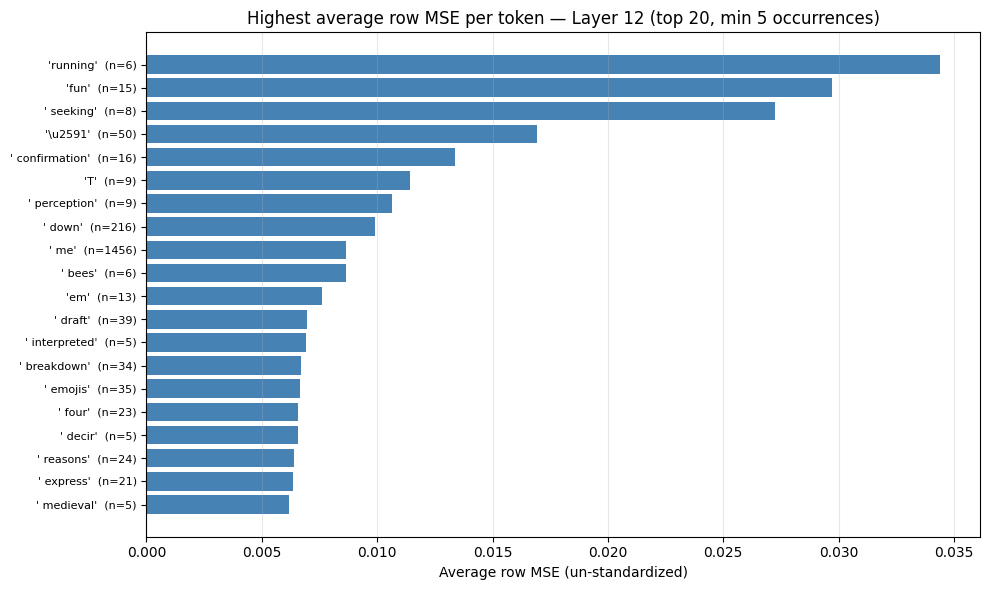

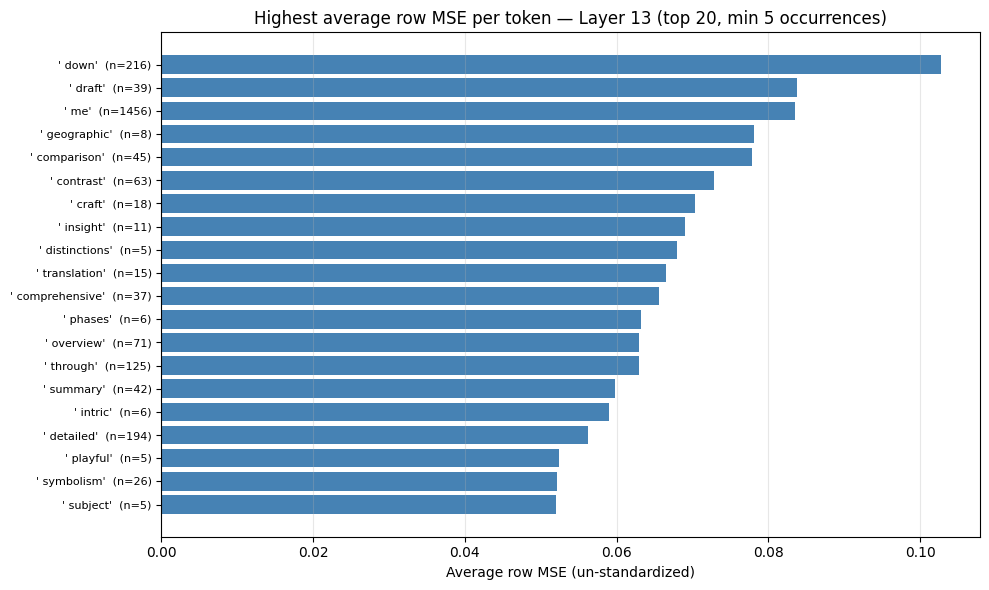

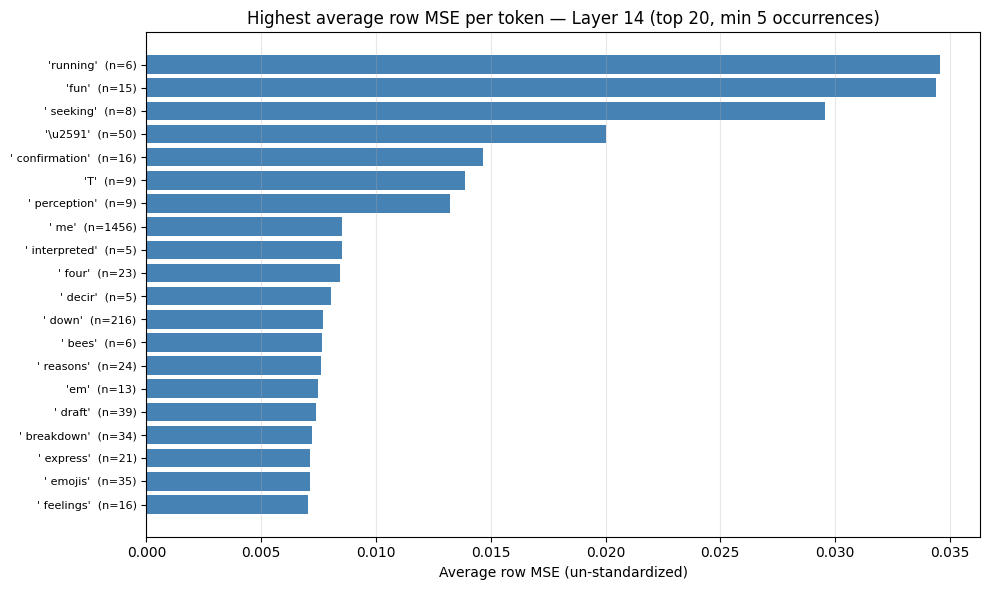

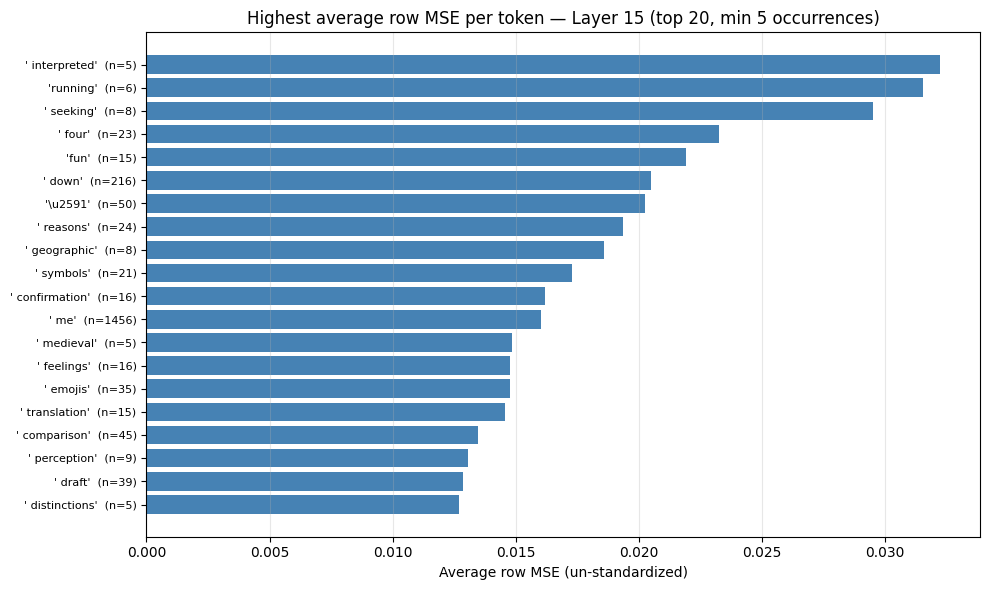

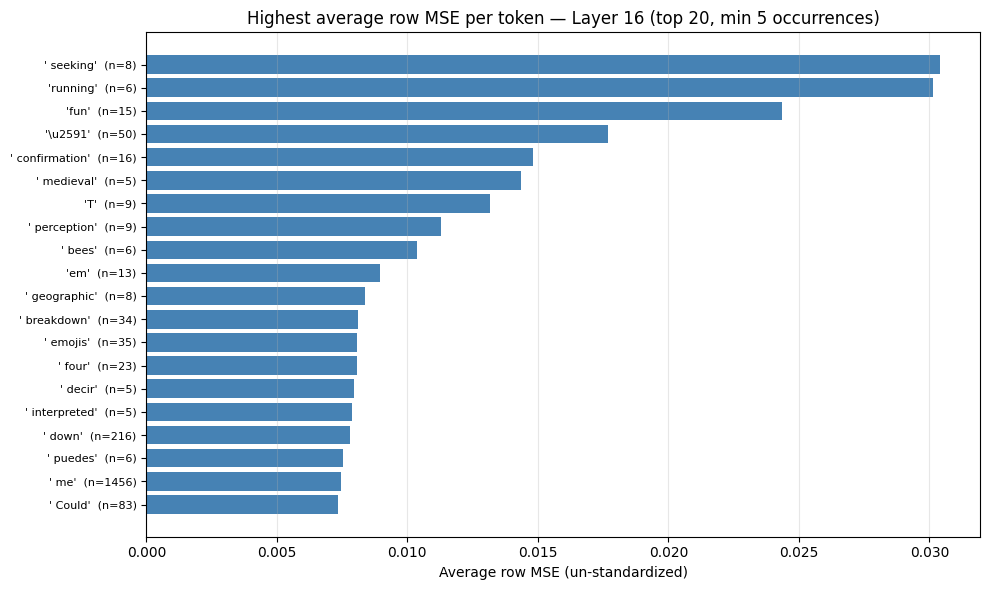

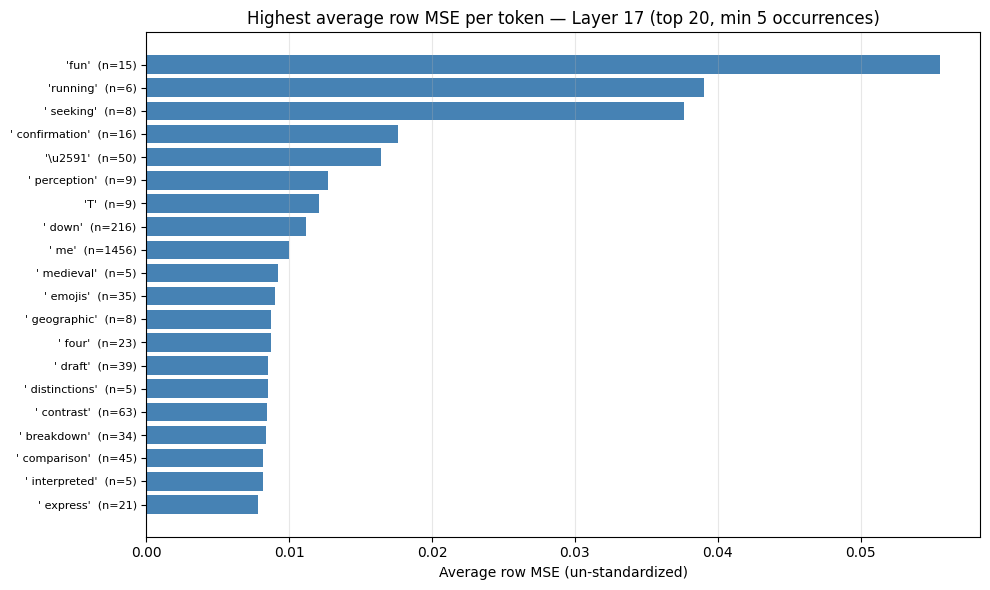

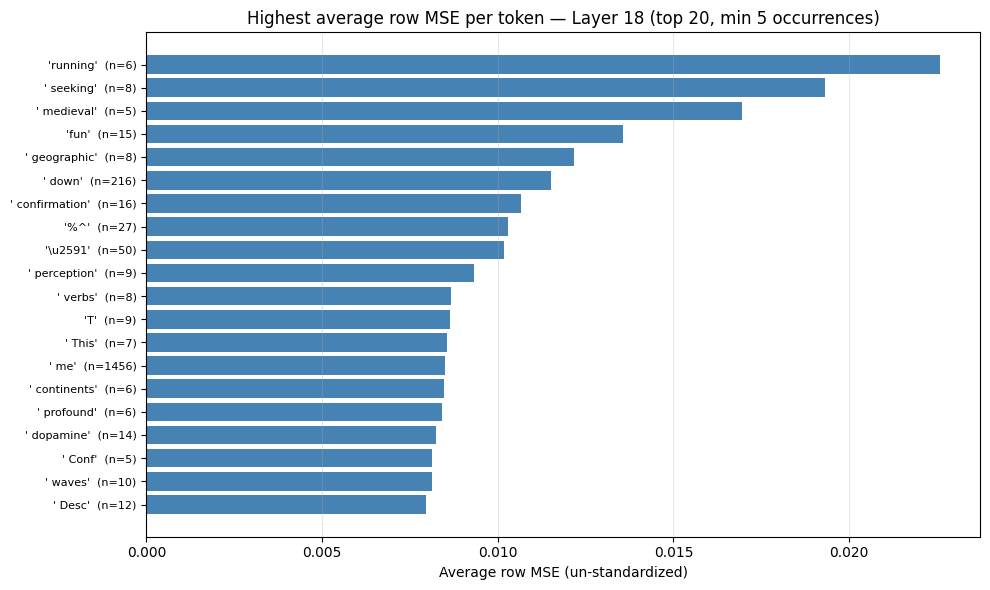

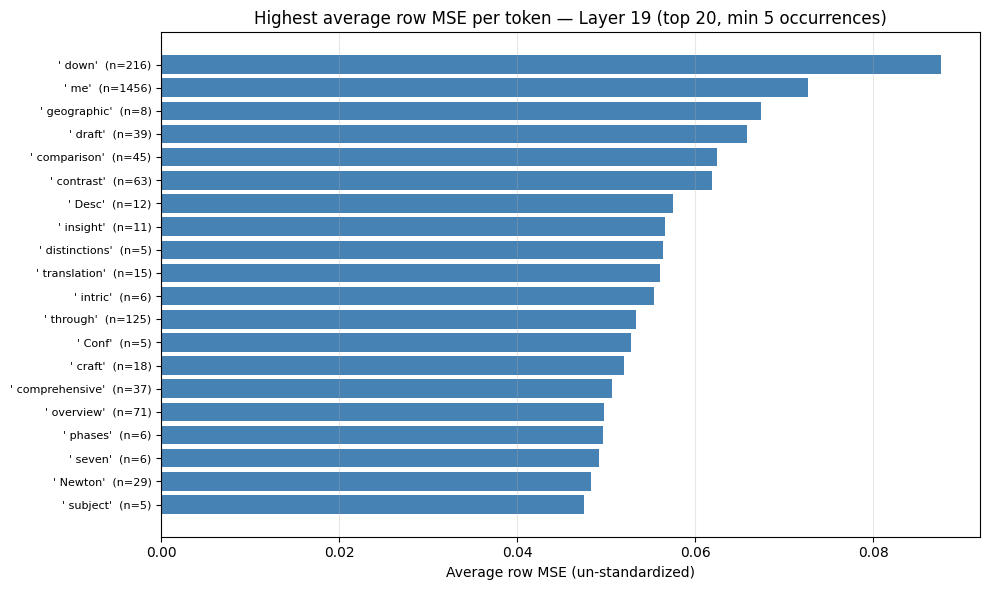

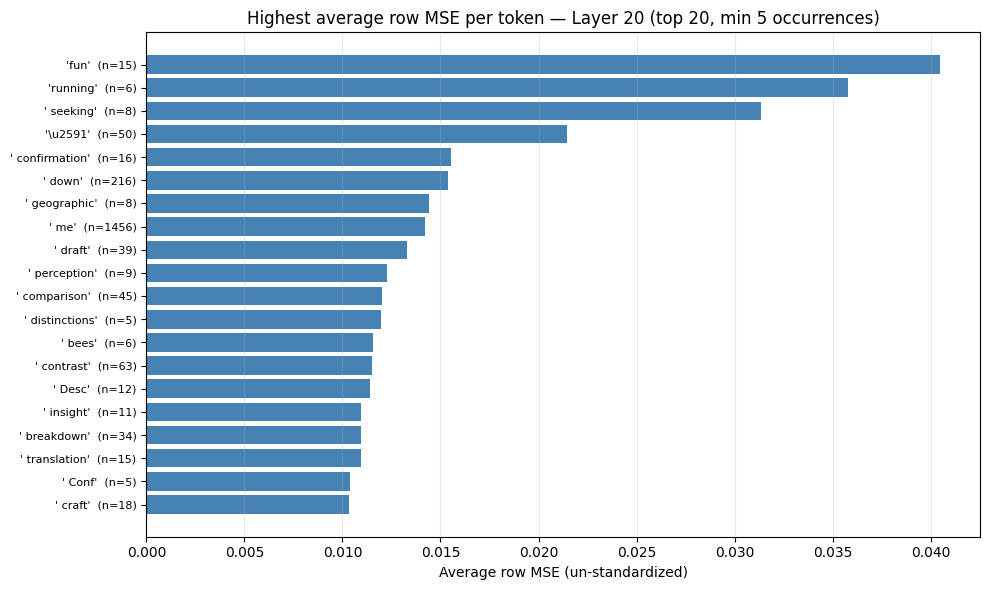

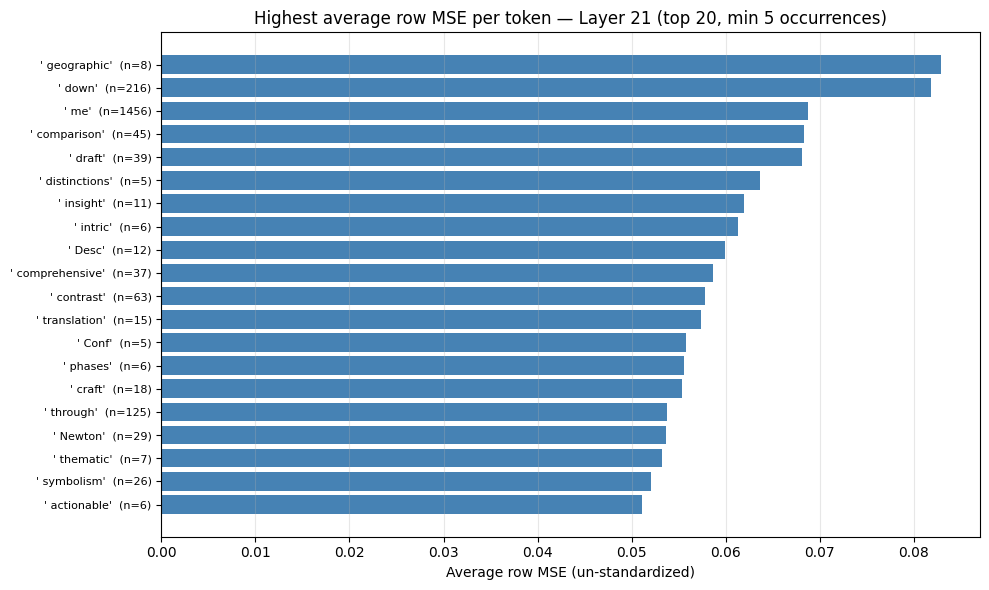

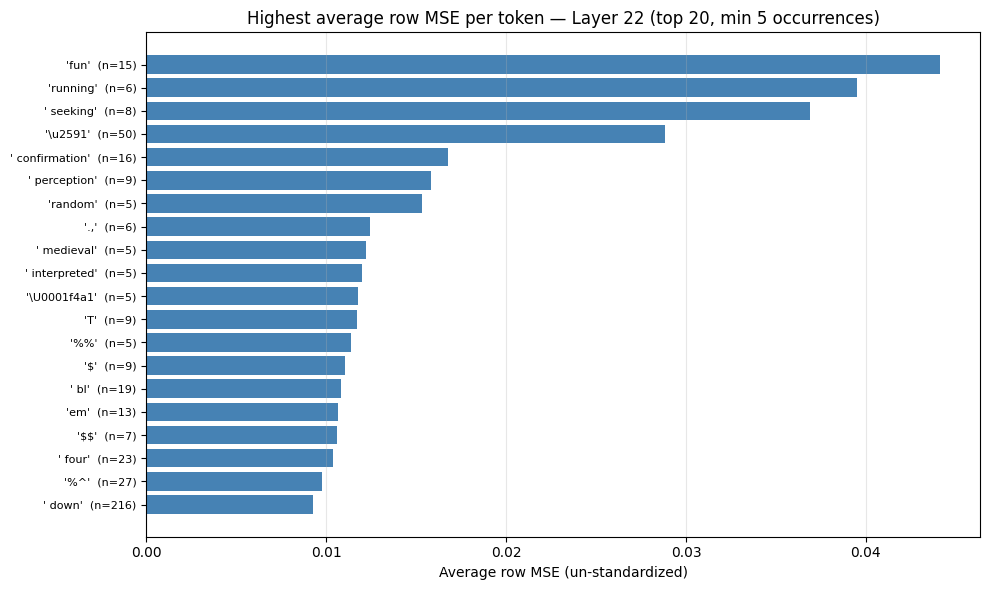

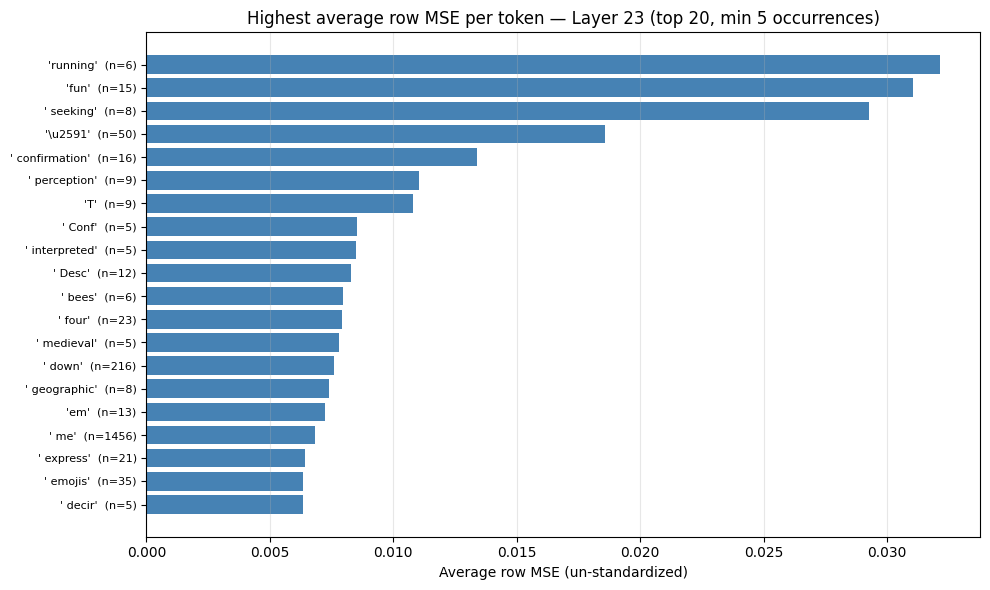

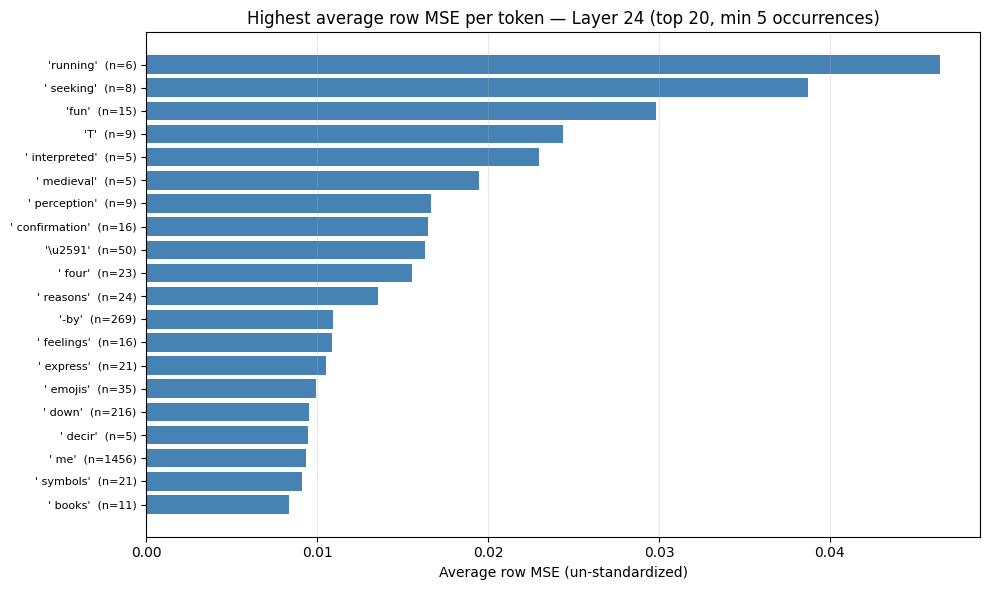

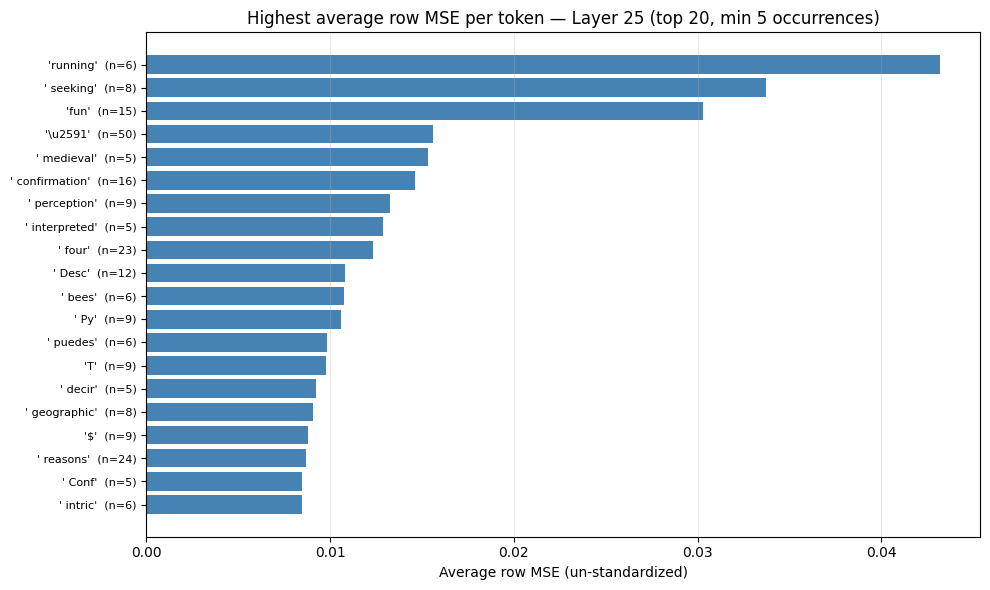

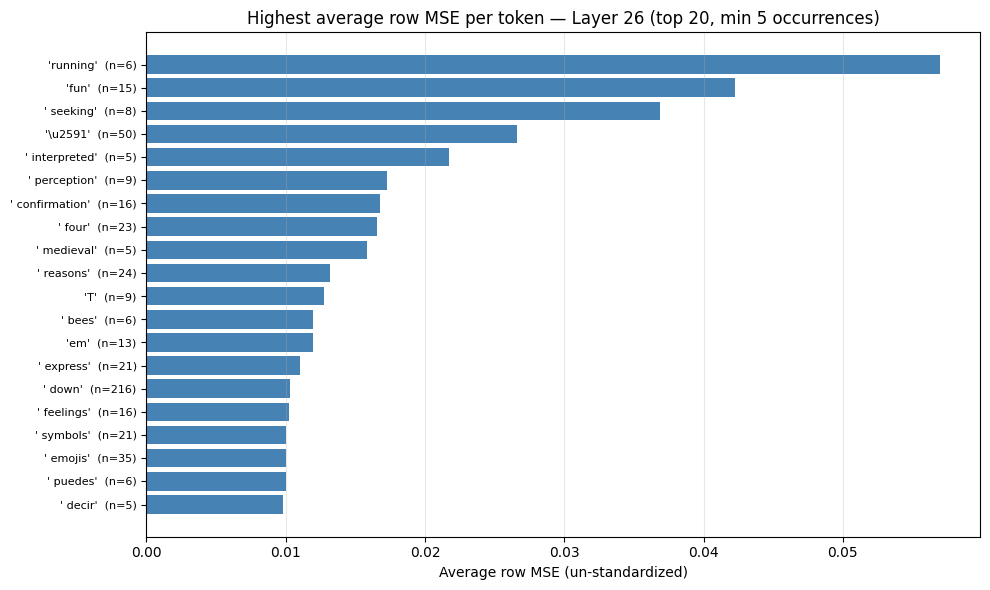

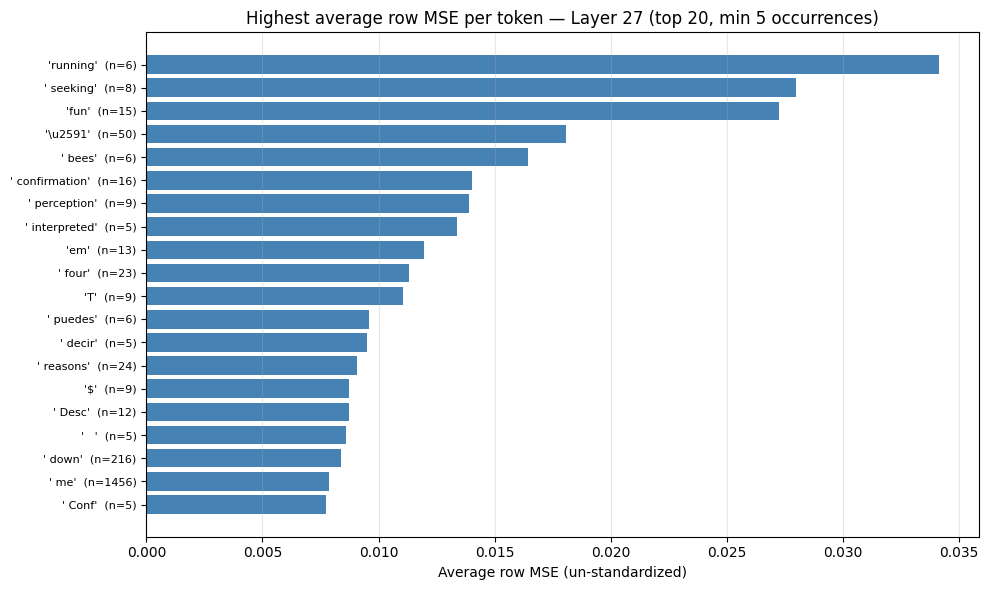

In [38]:
import matplotlib
matplotlib.rcParams['text.parse_math'] = False

# ── Change this to plot a different layer ──
for MSE_HIST_LAYER in range(28):
    TOP_K = 20
    MIN_COUNT = 5
    layer_data = token_mse[MSE_HIST_LAYER]
    avg_mse = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
    top = sorted(avg_mse.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    fig, ax = plt.subplots(figsize=(10, 6))
    if top:
        labels, vals = zip(*top)
        labels = [f"{ascii(l)}  (n={layer_data[l]['count']})" for l in labels]
        ax.barh(range(len(labels)), vals, color="steelblue")
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Average row MSE (un-standardized)")
        ax.grid(True, alpha=0.3, axis="x")
    ax.set_title(f"Highest average row MSE per token — Layer {MSE_HIST_LAYER} (top {TOP_K}, min {MIN_COUNT} occurrences)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

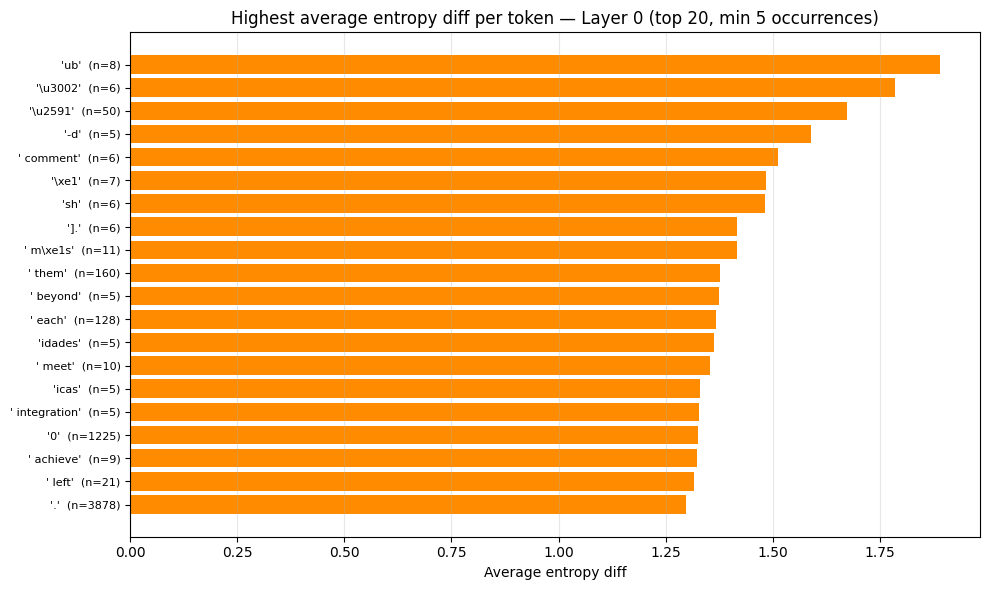

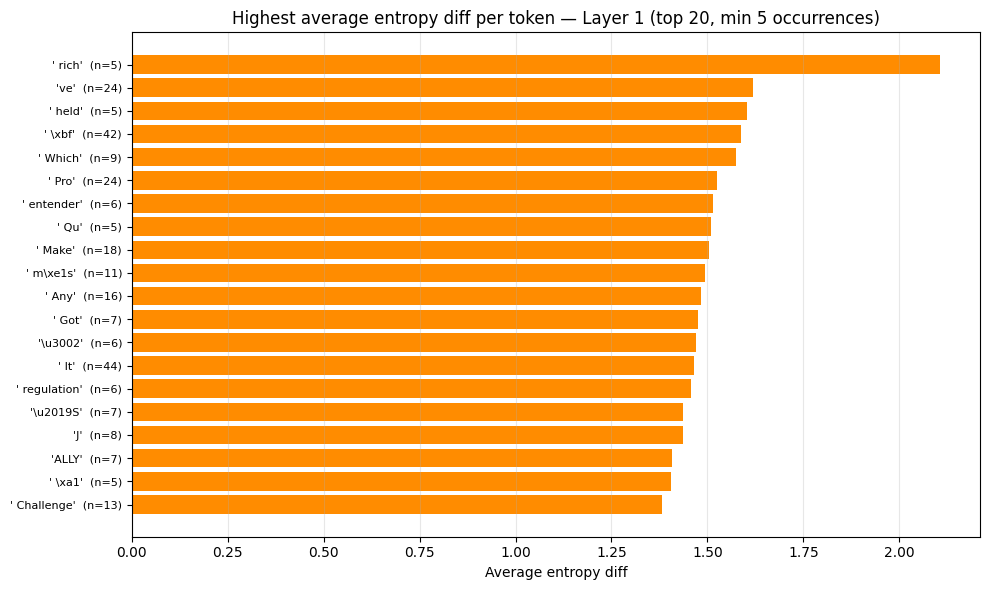

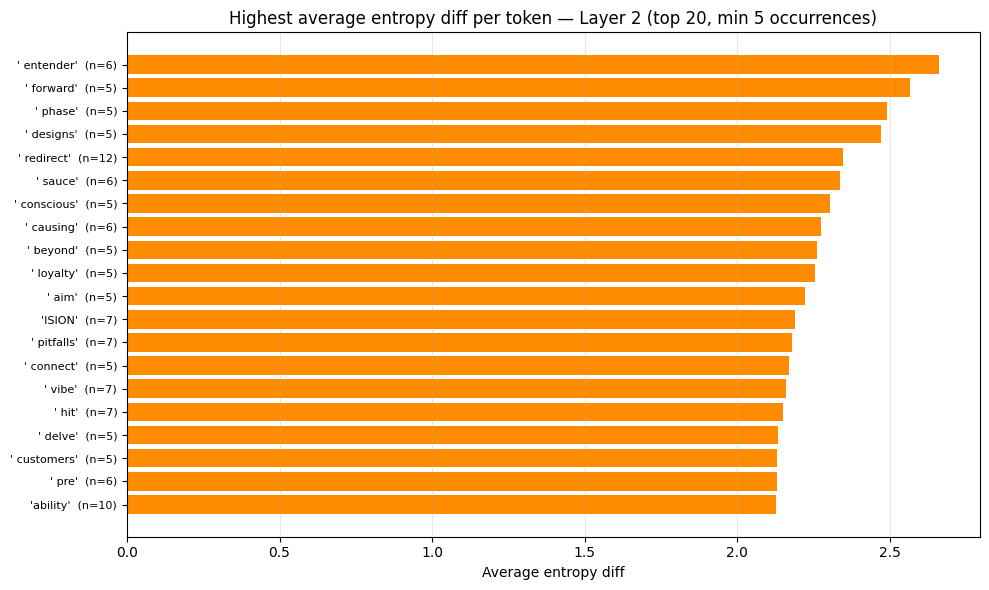

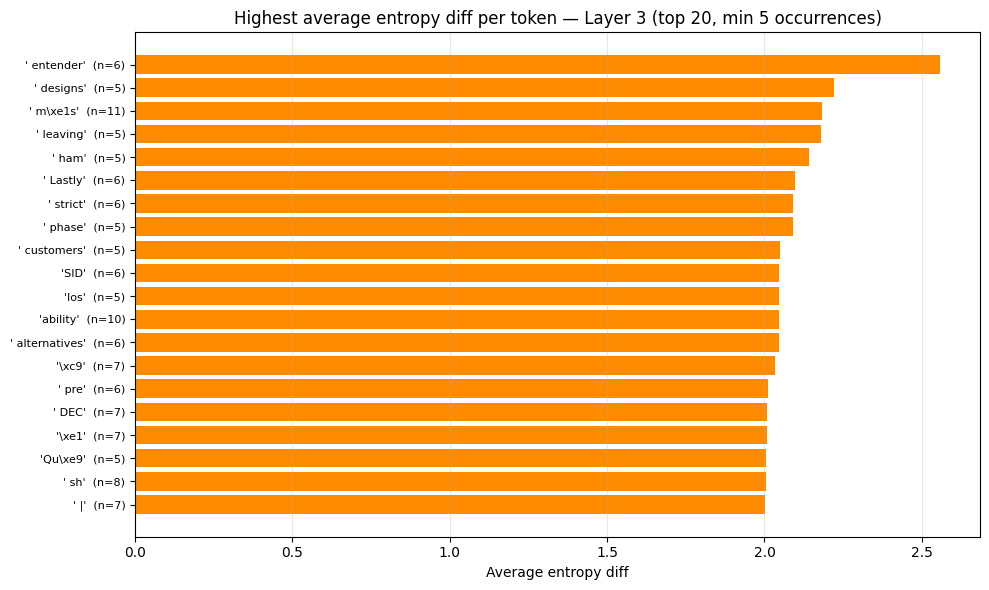

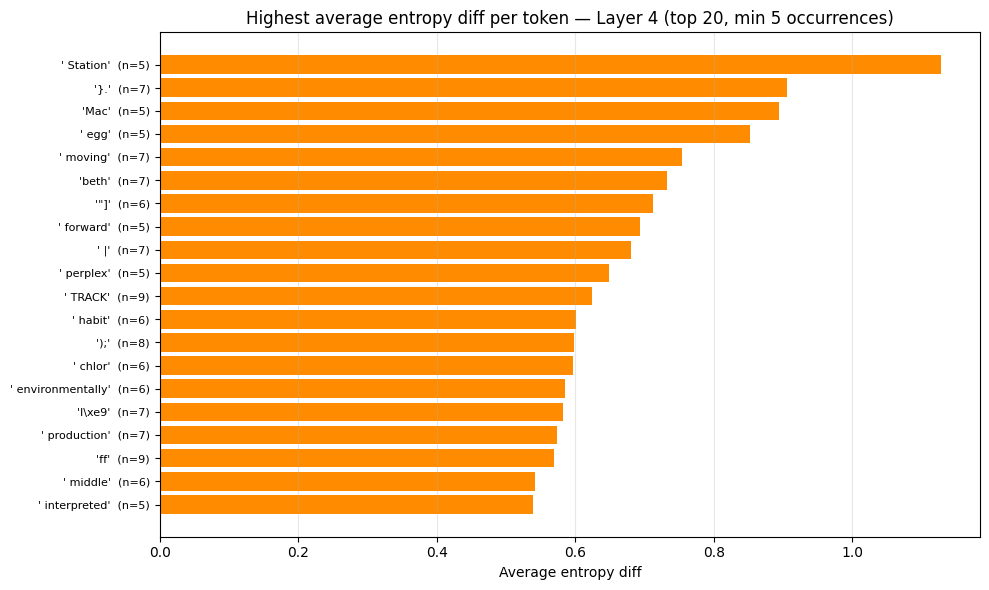

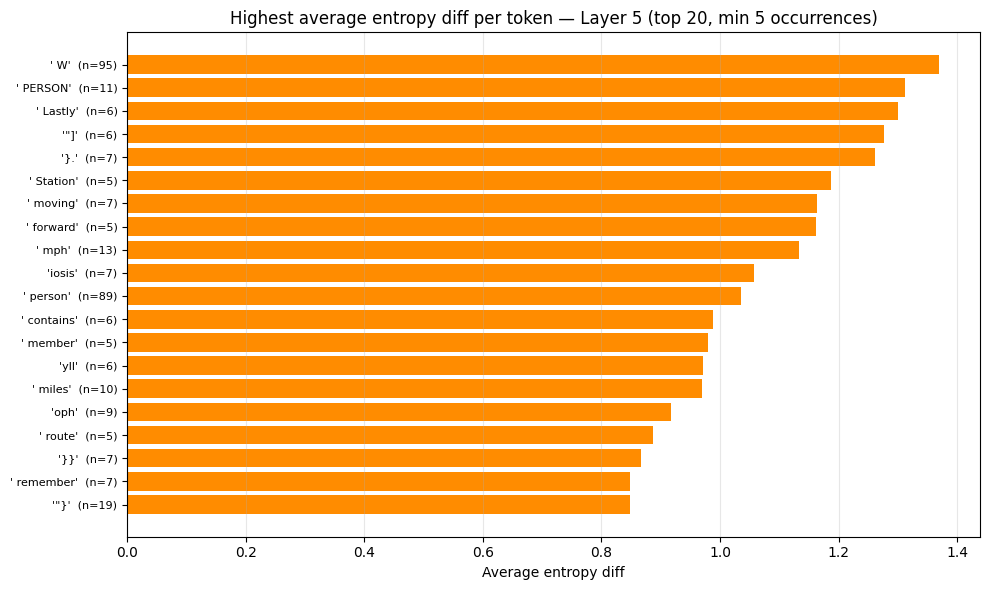

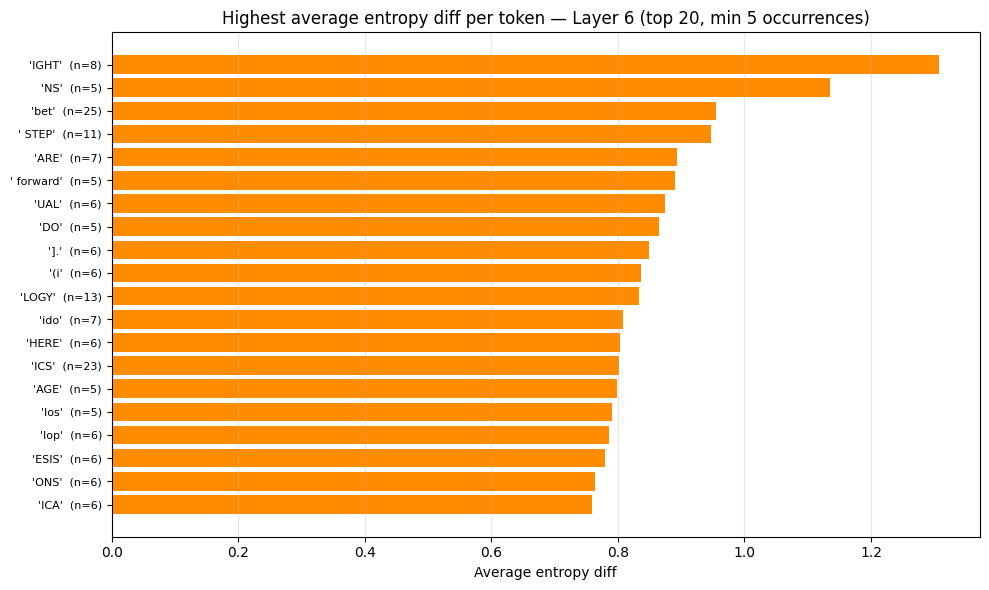

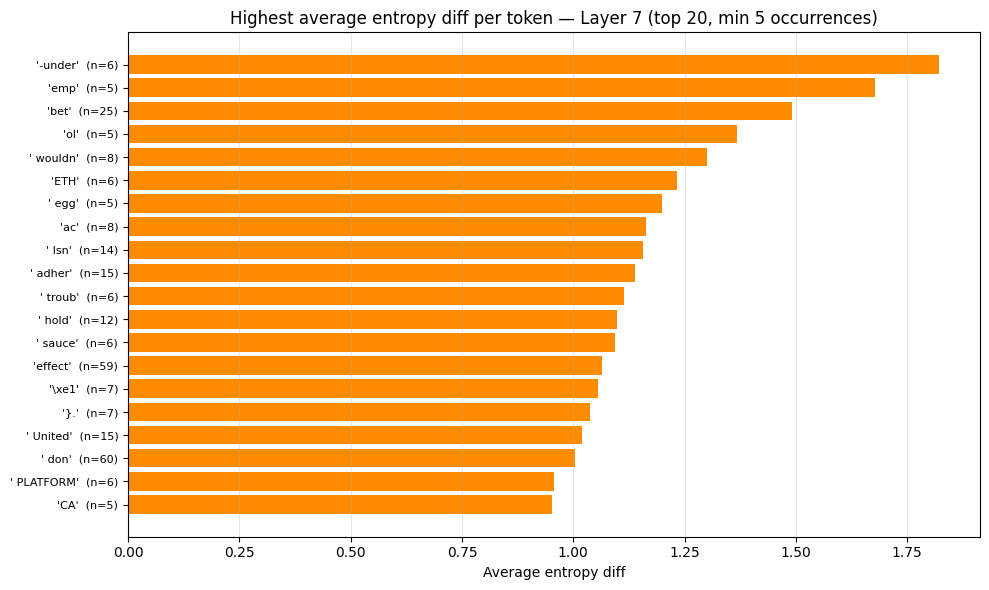

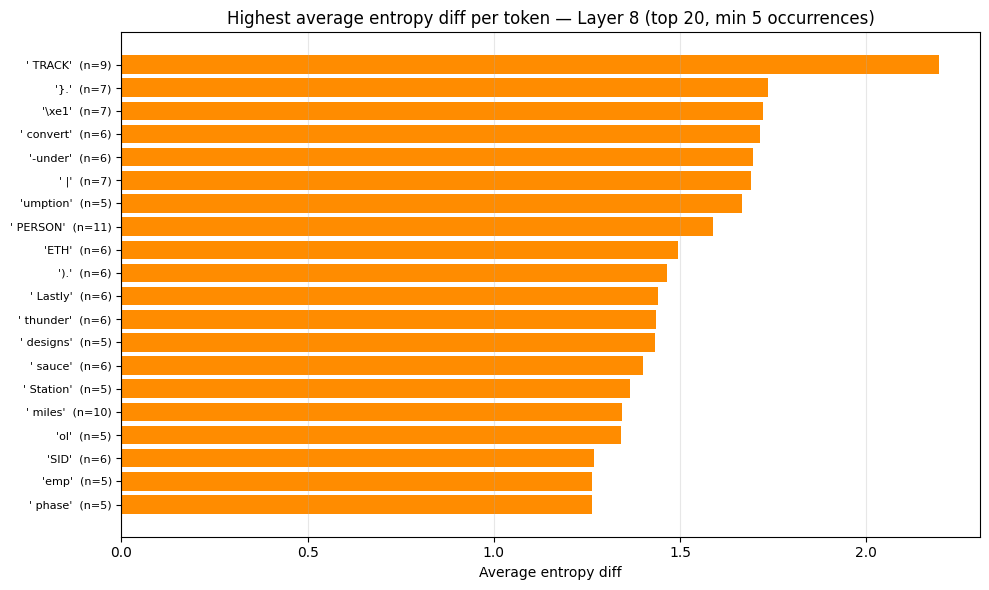

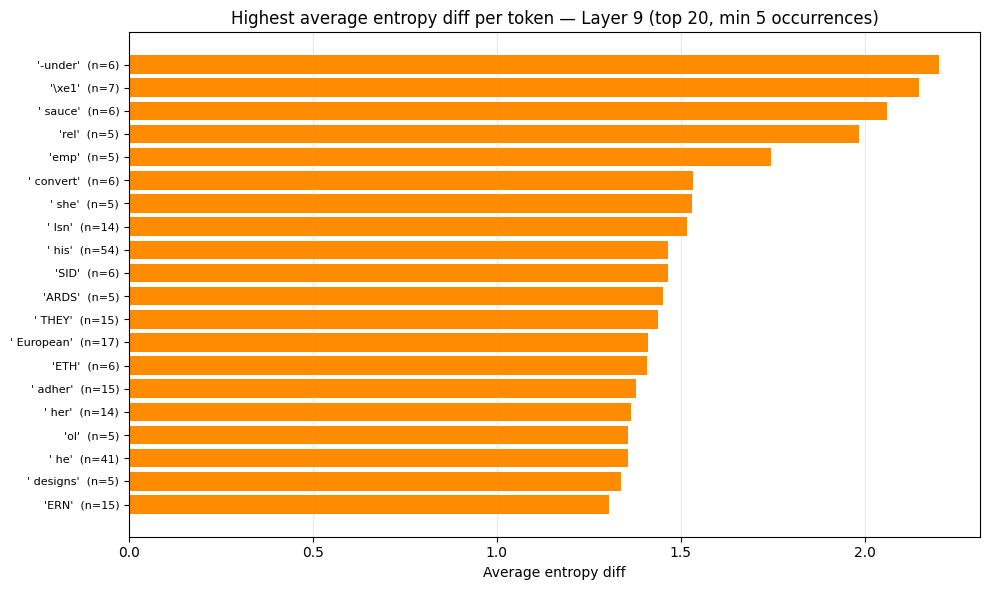

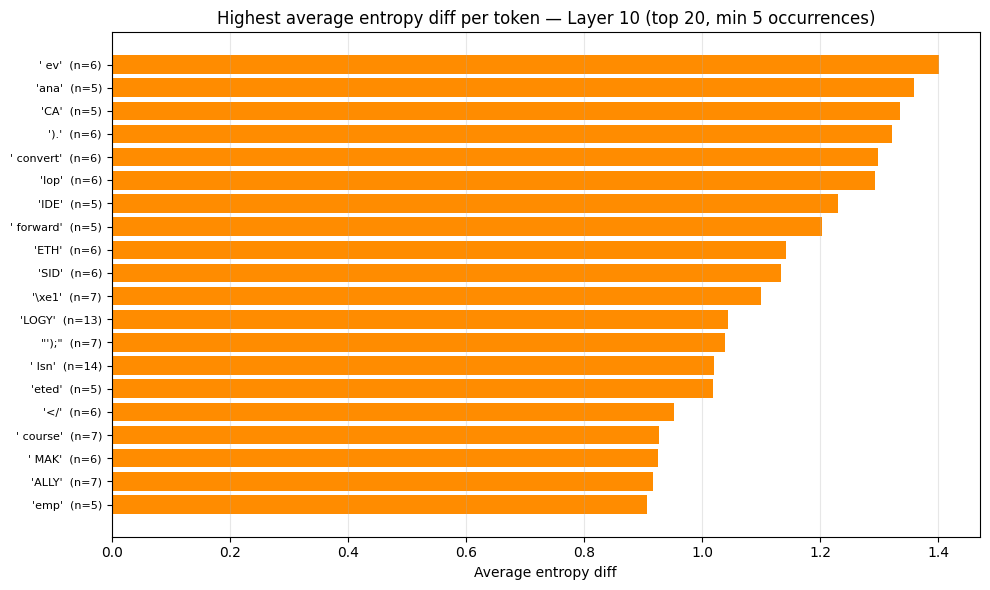

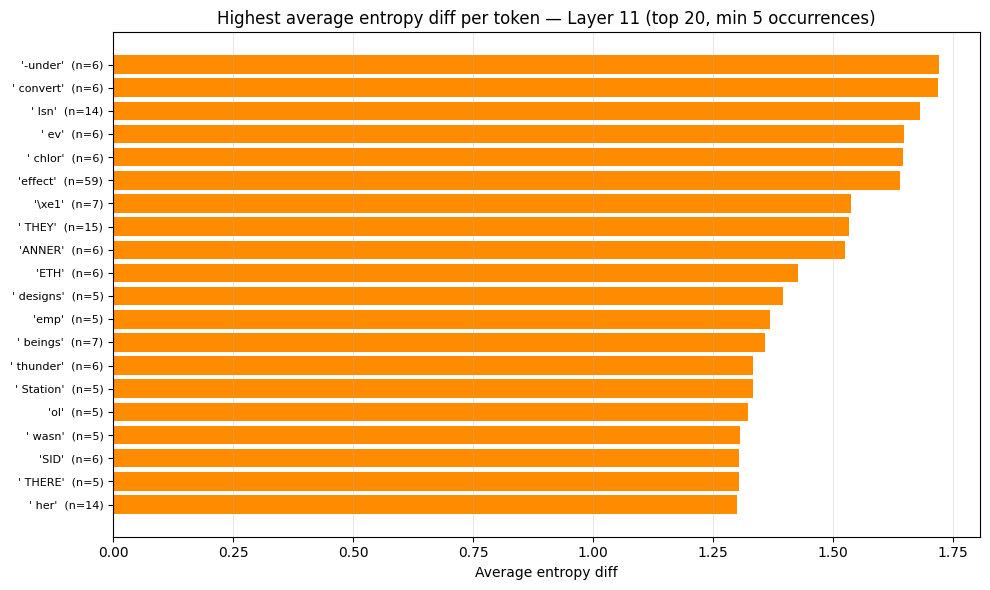

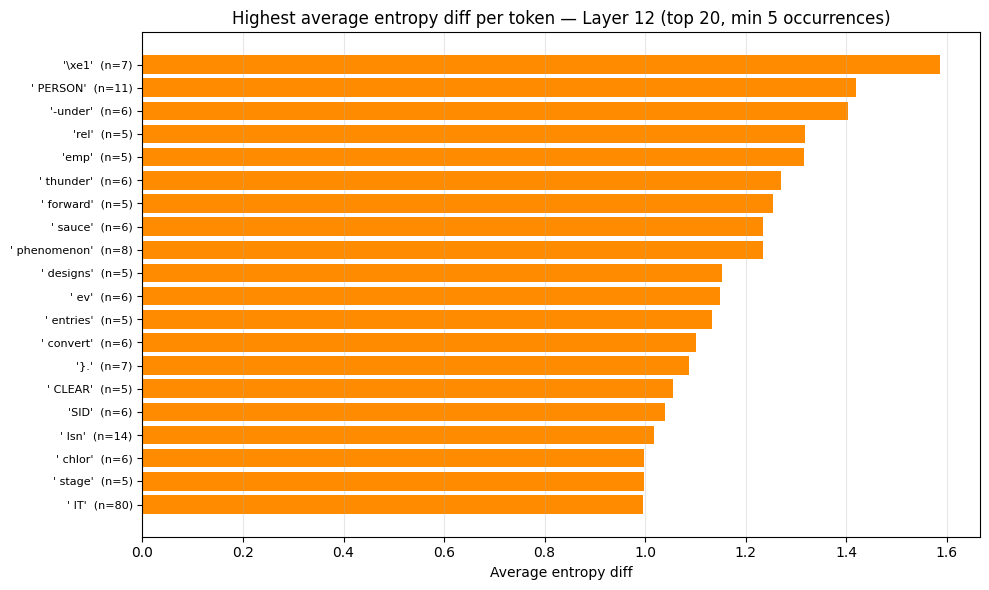

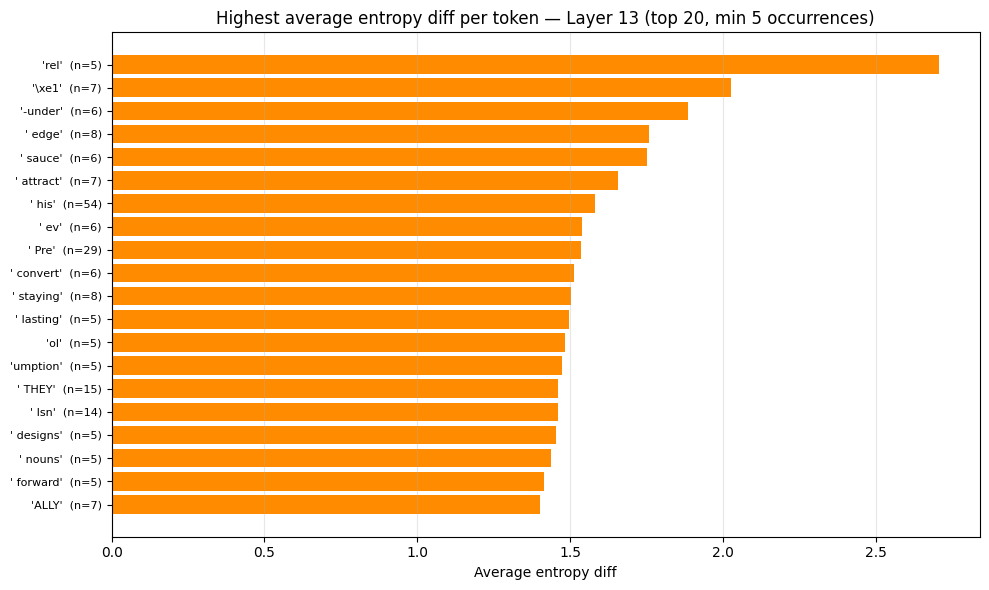

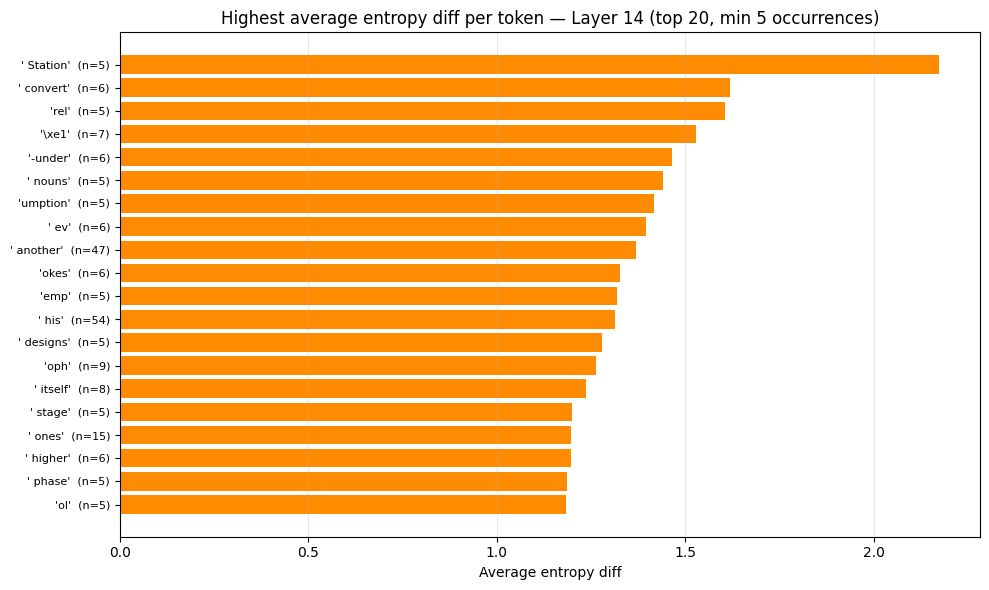

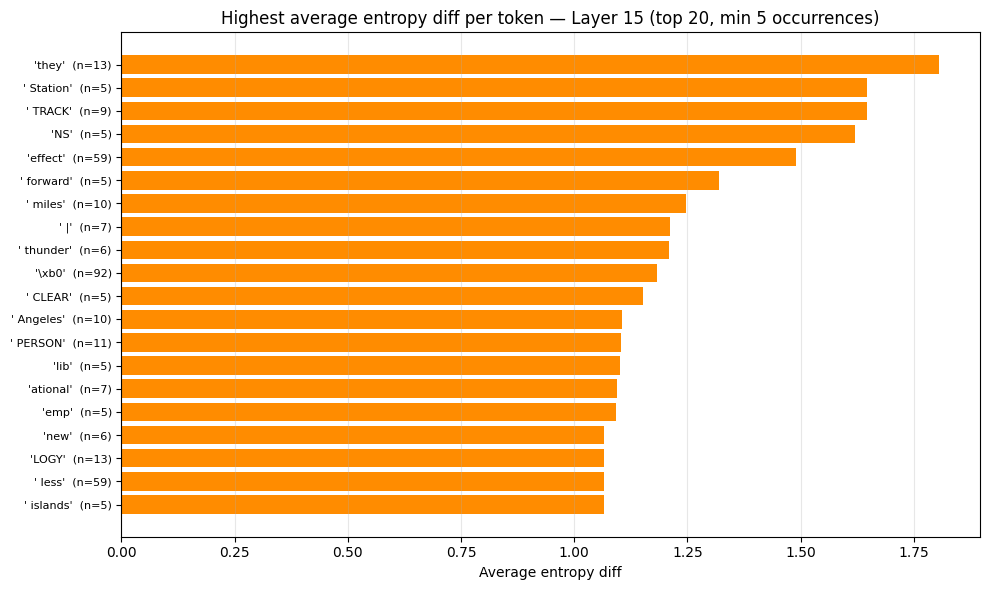

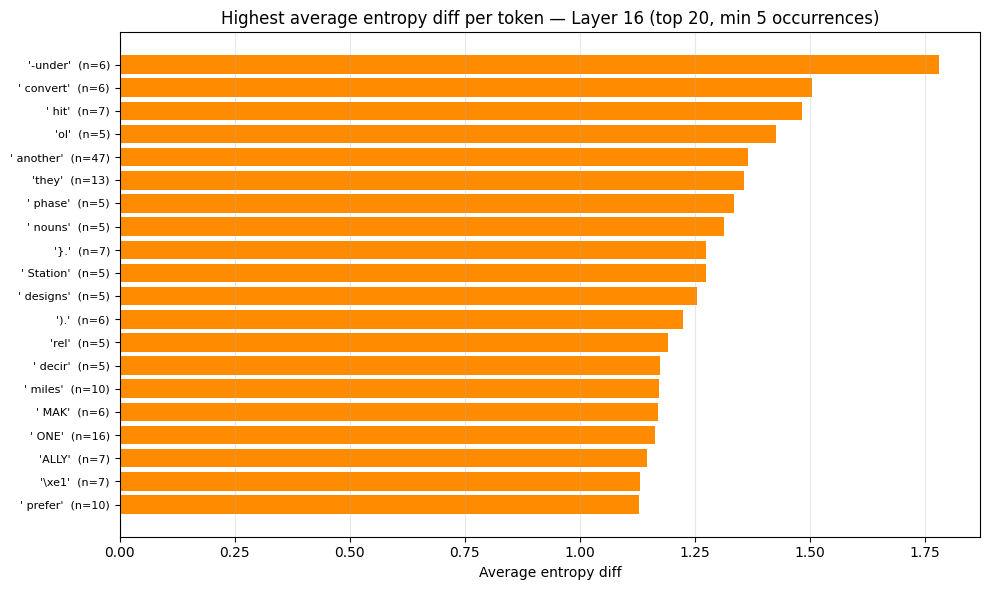

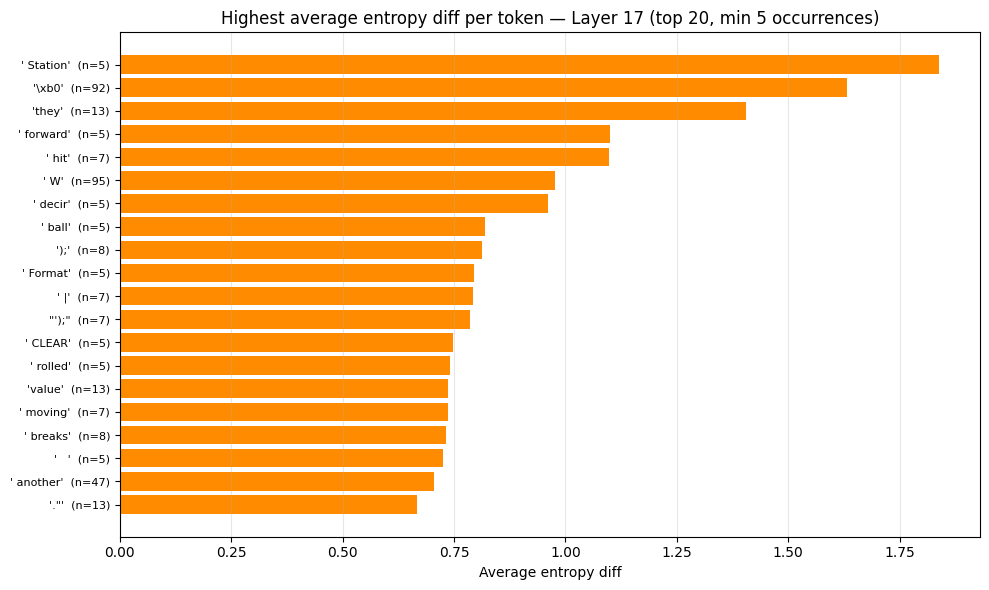

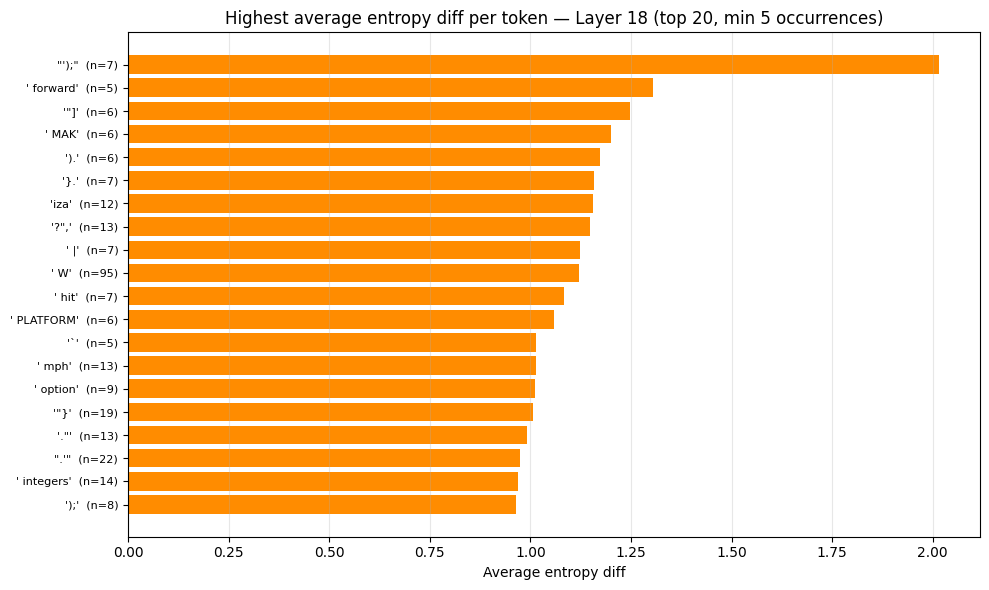

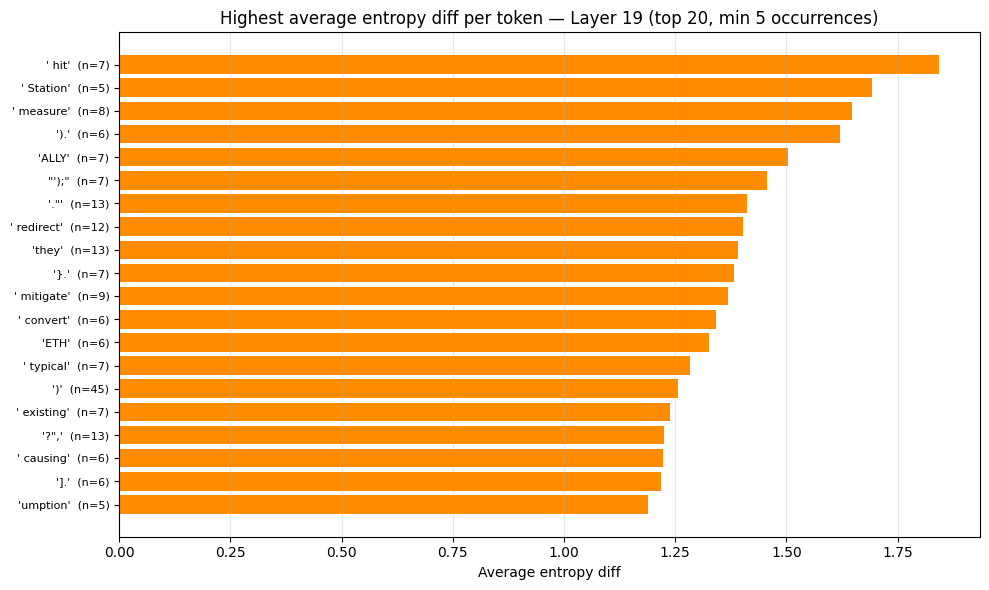

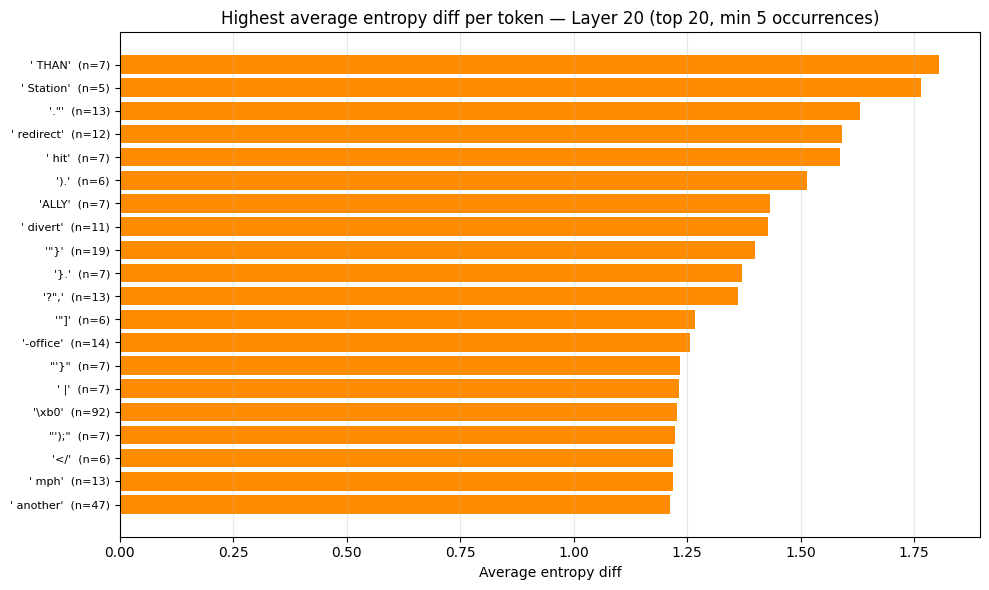

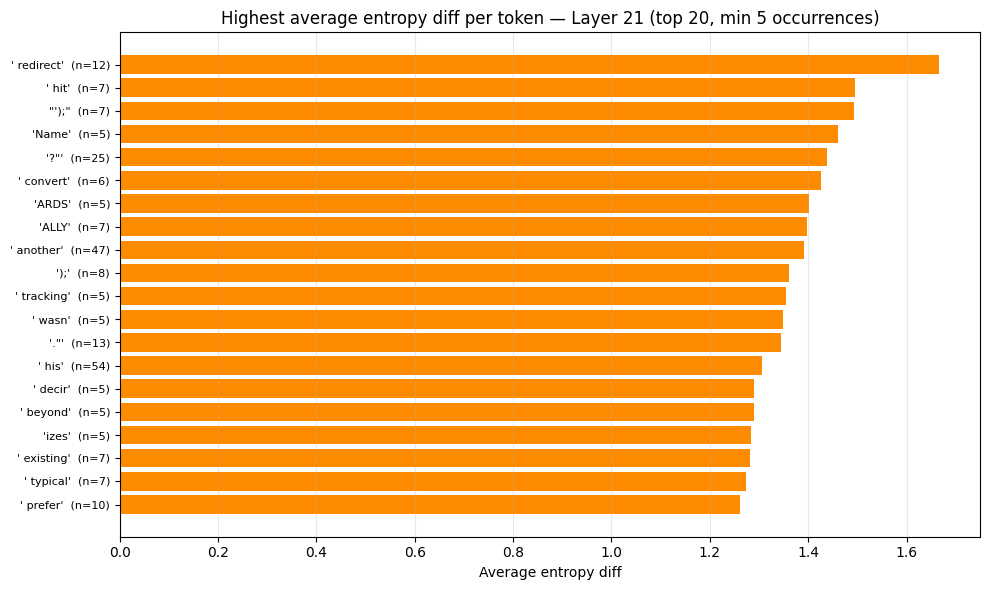

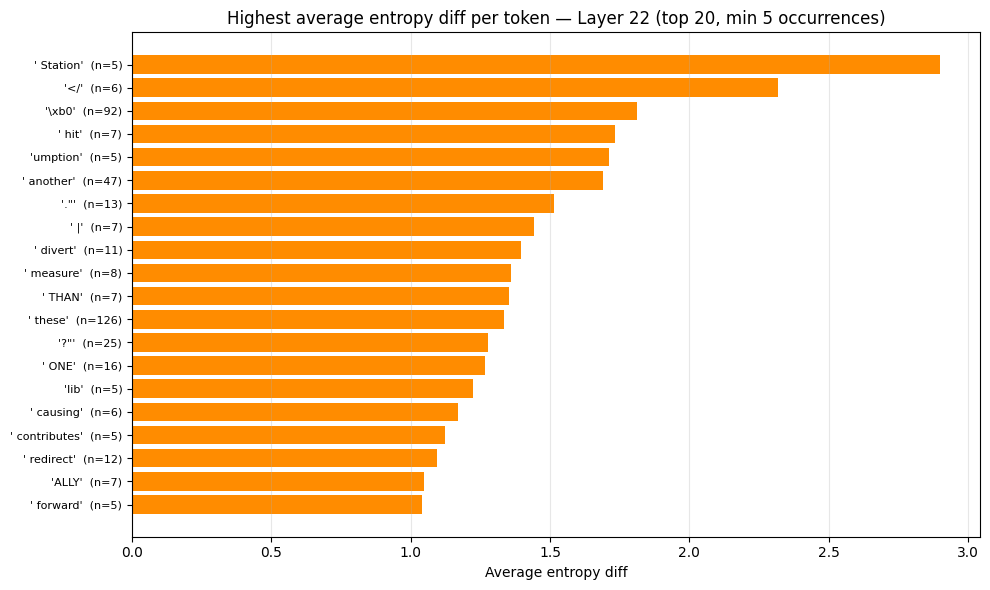

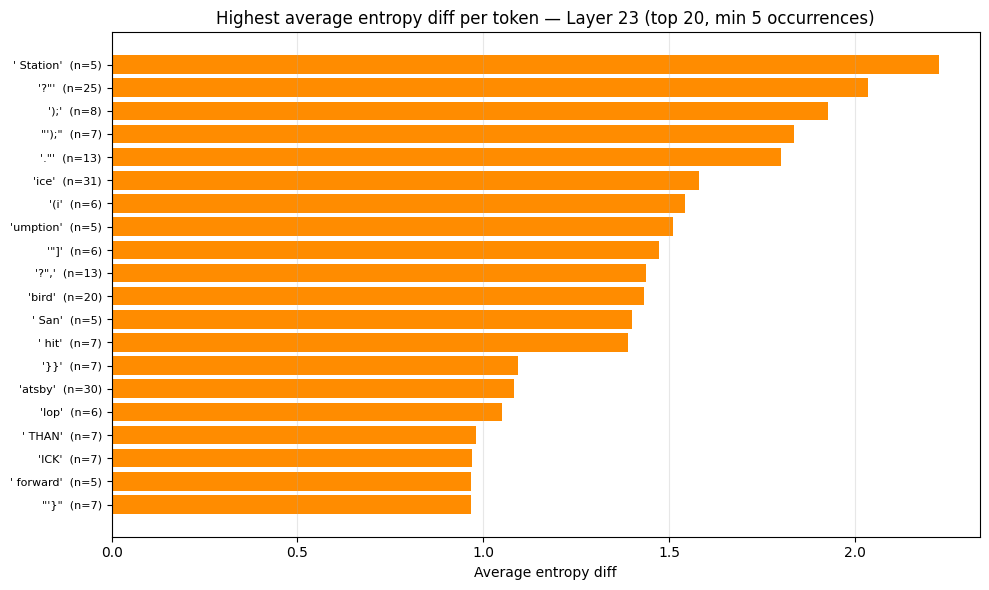

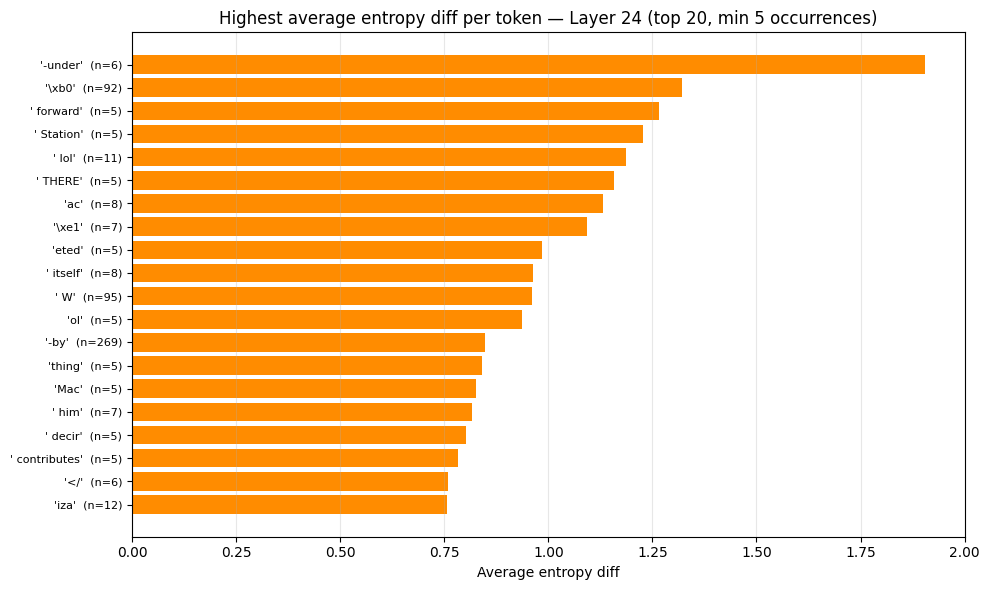

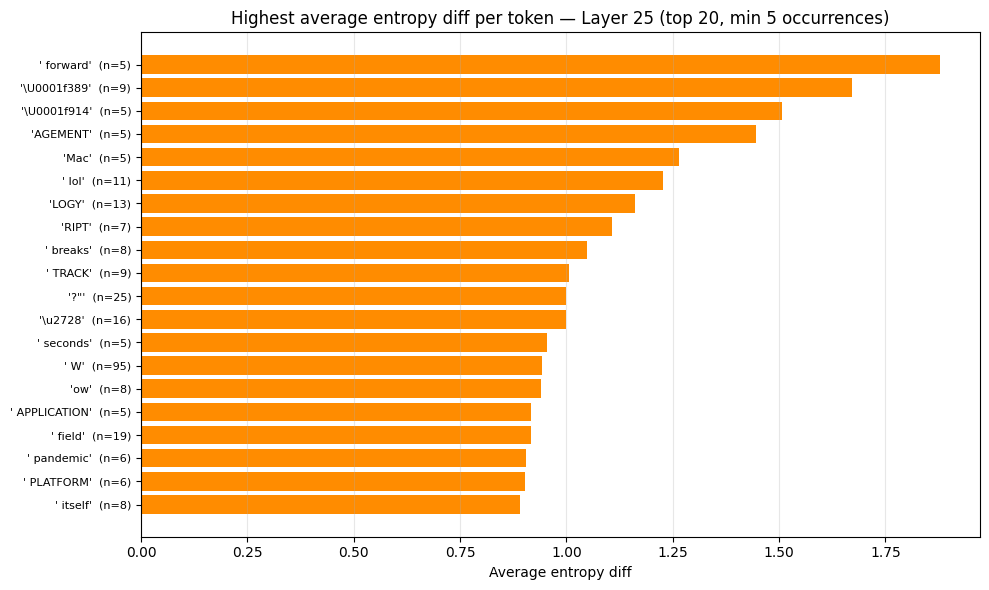

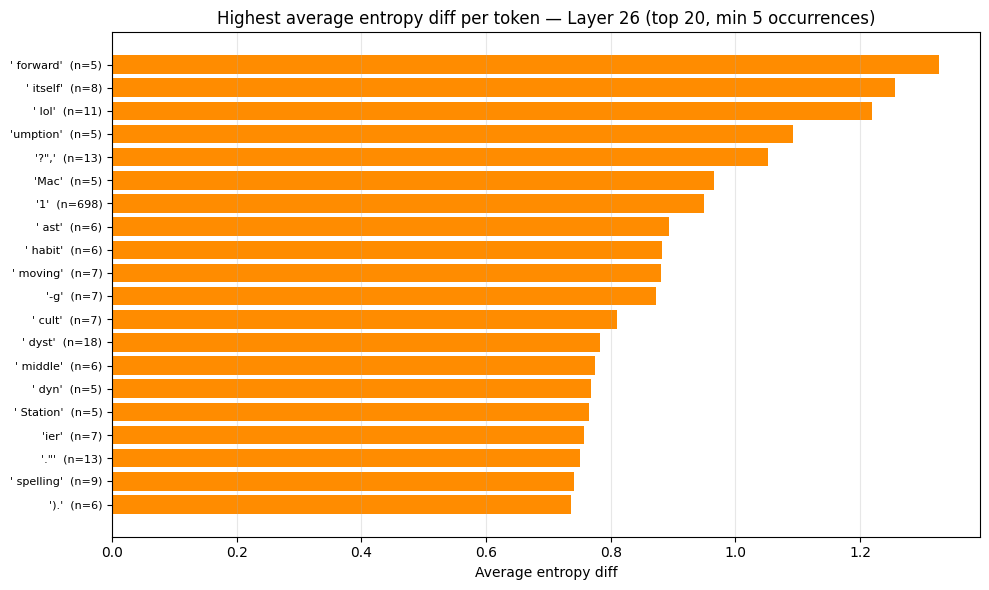

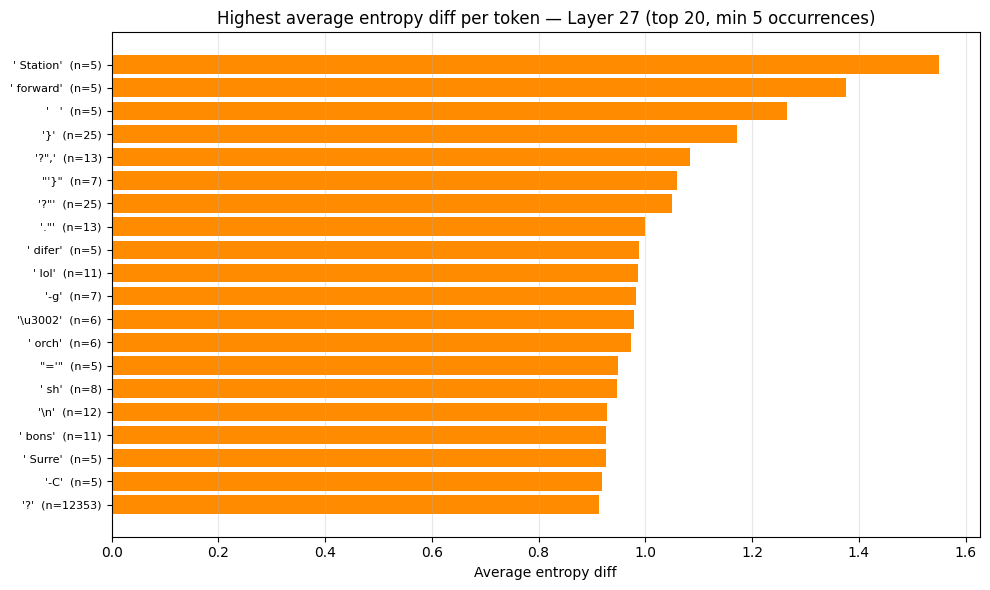

KeyError: 28

In [39]:
import matplotlib
matplotlib.rcParams['text.parse_math'] = False

# ── Change this to plot a different layer ──
for ENTROPY_HIST_LAYER in range(29):
    TOP_K = 20
    MIN_COUNT = 5
    layer_data = token_entropy[ENTROPY_HIST_LAYER]
    avg_ent = {tok: d["sum"] / d["count"] for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
    top = sorted(avg_ent.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    fig, ax = plt.subplots(figsize=(10, 6))
    if top:
        labels, vals = zip(*top)
        labels = [f"{ascii(l)}  (n={layer_data[l]['count']})" for l in labels]
        ax.barh(range(len(labels)), vals, color="darkorange")
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Average entropy diff")
        ax.grid(True, alpha=0.3, axis="x")
    ax.set_title(f"Highest average entropy diff per token — Layer {ENTROPY_HIST_LAYER} (top {TOP_K}, min {MIN_COUNT} occurrences)",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

In [40]:
# ── Print top tokens by average row MSE for each layer ──
TOP_K = 20
MIN_COUNT = 5

for MSE_HIST_LAYER in range(28):
    layer_data = token_mse[MSE_HIST_LAYER]
    avg_mse = {tok: d["sum"] / d["count"]
               for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
    top = sorted(avg_mse.items(), key=lambda x: x[1], reverse=True)[:TOP_K]

    print(f"\n{'='*70}")
    print(f"Layer {MSE_HIST_LAYER}  —  Top {TOP_K} tokens by average row MSE "
          f"(min {MIN_COUNT} occurrences)")
    print(f"{'='*70}")
    for rank, (tok, val) in enumerate(top, 1):
        n = layer_data[tok]["count"]
        print(f"  {rank:>2}. {ascii(tok):<30s}  avg_mse={val:.6f}  n={n}")


Layer 0  —  Top 20 tokens by average row MSE (min 5 occurrences)
   1. '\u3002'                        avg_mse=0.010339  n=6
   2. 'files'                         avg_mse=0.009518  n=5
   3. 'ographer'                      avg_mse=0.008823  n=9
   4. ' diff'                         avg_mse=0.008777  n=6
   5. ' designer'                     avg_mse=0.008536  n=5
   6. ' rule'                         avg_mse=0.008447  n=8
   7. ' .'                            avg_mse=0.008297  n=6
   8. 'ian'                           avg_mse=0.008094  n=38
   9. ' engineer'                     avg_mse=0.007914  n=15
  10. 'ist'                           avg_mse=0.007857  n=60
  11. 'ser'                           avg_mse=0.007807  n=10
  12. ' trainer'                      avg_mse=0.007744  n=5
  13. '.,'                            avg_mse=0.007569  n=6
  14. ' Or'                           avg_mse=0.007535  n=9
  15. ' the'                          avg_mse=0.007516  n=6741
  16. '.COM'               

In [41]:
# ── Print top tokens by average entropy diff for each layer ──
TOP_K = 20
MIN_COUNT = 5

for ENTROPY_HIST_LAYER in range(28):
    layer_data = token_entropy[ENTROPY_HIST_LAYER]
    avg_ent = {tok: d["sum"] / d["count"]
               for tok, d in layer_data.items() if d["count"] >= MIN_COUNT}
    top = sorted(avg_ent.items(), key=lambda x: x[1], reverse=True)[:TOP_K]

    print(f"\n{'='*70}")
    print(f"Layer {ENTROPY_HIST_LAYER}  —  Top {TOP_K} tokens by average entropy diff "
          f"(min {MIN_COUNT} occurrences)")
    print(f"{'='*70}")
    for rank, (tok, val) in enumerate(top, 1):
        n = layer_data[tok]["count"]
        print(f"  {rank:>2}. {ascii(tok):<30s}  avg_ent={val:.6f}  n={n}")


Layer 0  —  Top 20 tokens by average entropy diff (min 5 occurrences)
   1. 'ub'                            avg_ent=1.889381  n=8
   2. '\u3002'                        avg_ent=1.785103  n=6
   3. '\u2591'                        avg_ent=1.672769  n=50
   4. '-d'                            avg_ent=1.590218  n=5
   5. ' comment'                      avg_ent=1.513434  n=6
   6. '\xe1'                          avg_ent=1.483185  n=7
   7. 'sh'                            avg_ent=1.481595  n=6
   8. '].'                            avg_ent=1.417593  n=6
   9. ' m\xe1s'                       avg_ent=1.417355  n=11
  10. ' them'                         avg_ent=1.376929  n=160
  11. ' beyond'                       avg_ent=1.374685  n=5
  12. ' each'                         avg_ent=1.367269  n=128
  13. 'idades'                        avg_ent=1.363559  n=5
  14. ' meet'                         avg_ent=1.354372  n=10
  15. 'icas'                          avg_ent=1.329509  n=5
  16. ' integration'  